



# Load the libraries

In [542]:

!pip install inequality mapclassify libpysal geopandas seaborn watermark

import inequality as ineq
import numpy as np
import pandas as pd
import geopandas as gpd
import libpysal as lps
import seaborn as sns
import matplotlib.pyplot as plt
import watermark
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import mapclassify

!pip install splot


!pip install splot


!pip install tslearn --quiet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance









# The dataset

Dataset includes gdp per capita over the years 2004-2023 for 81 provinces
(NUTS-III) for Turkiye. RegionID, subregionID, provinceID columns represent the NUTS-I,  (12 regions total), NUTS-II (26 regions) and  NUTS-III (81 provinces), respectively.

In [545]:


gdp = pd.read_excel('https://raw.githubusercontent.com/ugurursavas/spatial_inequalities_turkiye/main/wide_income_pc_data_3.xlsx')
geo = gpd.read_file('https://raw.githubusercontent.com/ugurursavas/spatial_inequalities_turkiye/main/TUR_ADM1.geojson')

gdf = geo.merge(gdp, on='asdf_id')
gdf.head()

gdf.head()



,id,Level,asdf_id,gqid,shapeGroup,shapeID,shapeISO,shapeName_x,shapeType,geometry,...,gdppc_2014,gdppc_2015,gdppc_2016,gdppc_2017,gdppc_2018,gdppc_2019,gdppc_2020,gdppc_2021,gdppc_2022,gdppc_2023
0,0,ADM1,0,0,TUR,TUR-ADM1-80719077B77822815,TR-01,Adana,ADM1,"MULTIPOLYGON (((35.38791 36.55628, 35.38883 36...",...,13171.396314,13877.767024,14435.589802,14946.317915,14815.580204,14956.374166,15810.963122,17545.489851,18747.219787,20049.204113
1,1,ADM1,1,1,TUR,TUR-ADM1-80719077B28599679,TR-02,Adıyaman,ADM1,"POLYGON ((37.861 37.46666, 37.87451 37.46648, ...",...,8010.685223,8503.908596,8609.806318,8988.842029,9215.684862,9292.833598,9871.413009,10472.984175,11180.636964,12994.522115
2,2,ADM1,2,2,TUR,TUR-ADM1-80719077B84550223,TR-03,Afyonkarahisar,ADM1,"POLYGON ((30.48061 38.19903, 30.49275 38.19655...",...,12730.464586,13244.313590,13931.617317,15223.499461,15264.136511,14922.779558,15030.093145,15564.626253,16125.684398,16669.864935
3,3,ADM1,3,3,TUR,TUR-ADM1-80719077B65173278,TR-04,Ağrı,ADM1,"POLYGON ((43.77542 39.25004, 43.79639 39.26875...",...,5524.034690,5817.799382,6527.340458,6563.299365,6673.627878,6787.884722,7363.297132,7682.336975,8429.087042,9370.543661
4,4,ADM1,4,4,TUR,TUR-ADM1-80719077B72380009,TR-05,Amasya,ADM1,"POLYGON ((36.3878 40.66228, 36.39811 40.67508,...",...,12813.235253,14000.332126,14521.723543,15010.118586,14681.809024,14661.065719,15070.224803,15114.448112,16090.112249,16333.788866


In [546]:
gdf

,id,Level,asdf_id,gqid,shapeGroup,shapeID,shapeISO,shapeName_x,shapeType,geometry,...,gdppc_2014,gdppc_2015,gdppc_2016,gdppc_2017,gdppc_2018,gdppc_2019,gdppc_2020,gdppc_2021,gdppc_2022,gdppc_2023
0,0,ADM1,0,0,TUR,TUR-ADM1-80719077B77822815,TR-01,Adana,ADM1,"MULTIPOLYGON (((35.38791 36.55628, 35.38883 36...",...,13171.396314,13877.767024,14435.589802,14946.317915,14815.580204,14956.374166,15810.963122,17545.489851,18747.219787,20049.204113
1,1,ADM1,1,1,TUR,TUR-ADM1-80719077B28599679,TR-02,Adıyaman,ADM1,"POLYGON ((37.861 37.46666, 37.87451 37.46648, ...",...,8010.685223,8503.908596,8609.806318,8988.842029,9215.684862,9292.833598,9871.413009,10472.984175,11180.636964,12994.522115
2,2,ADM1,2,2,TUR,TUR-ADM1-80719077B84550223,TR-03,Afyonkarahisar,ADM1,"POLYGON ((30.48061 38.19903, 30.49275 38.19655...",...,12730.464586,13244.313590,13931.617317,15223.499461,15264.136511,14922.779558,15030.093145,15564.626253,16125.684398,16669.864935
3,3,ADM1,3,3,TUR,TUR-ADM1-80719077B65173278,TR-04,Ağrı,ADM1,"POLYGON ((43.77542 39.25004, 43.79639 39.26875...",...,5524.034690,5817.799382,6527.340458,6563.299365,6673.627878,6787.884722,7363.297132,7682.336975,8429.087042,9370.543661
4,4,ADM1,4,4,TUR,TUR-ADM1-80719077B72380009,TR-05,Amasya,ADM1,"POLYGON ((36.3878 40.66228, 36.39811 40.67508,...",...,12813.235253,14000.332126,14521.723543,15010.118586,14681.809024,14661.065719,15070.224803,15114.448112,16090.112249,16333.788866
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,76,ADM1,76,76,TUR,TUR-ADM1-80719077B83749854,TR-77,Yalova,ADM1,"POLYGON ((29.4818 40.56397, 29.48439 40.56645,...",...,19866.078918,21652.936153,21839.877516,22126.901351,22634.490569,22475.573483,23494.033690,27038.776499,26753.193198,28692.302645
77,77,ADM1,77,77,TUR,TUR-ADM1-80719077B67647683,TR-66,Yozgat,ADM1,"POLYGON ((35.33995 40.25508, 35.28463 40.22667...",...,11430.562234,12017.072764,12480.012635,12324.590947,12459.947621,11982.205603,13098.397738,12818.537634,13752.625214,14380.267127
78,78,ADM1,78,78,TUR,TUR-ADM1-80719077B51620989,TR-67,Zonguldak,ADM1,"MULTIPOLYGON (((31.85365 41.0083, 31.88498 41....",...,12651.585849,13177.270950,13149.314505,13975.439443,13504.482256,12416.632414,13601.249315,15010.549718,15855.171535,14686.616218
79,79,ADM1,79,79,TUR,TUR-ADM1-80719077B759750,TR-73,Şırnak,ADM1,"POLYGON ((43.49919 37.74179, 43.43868 37.74784...",...,8891.714352,9069.779919,8895.460408,10522.474545,10842.248040,11132.955071,11912.868518,13002.109446,12911.824679,14993.943004


# Plot maps and figures

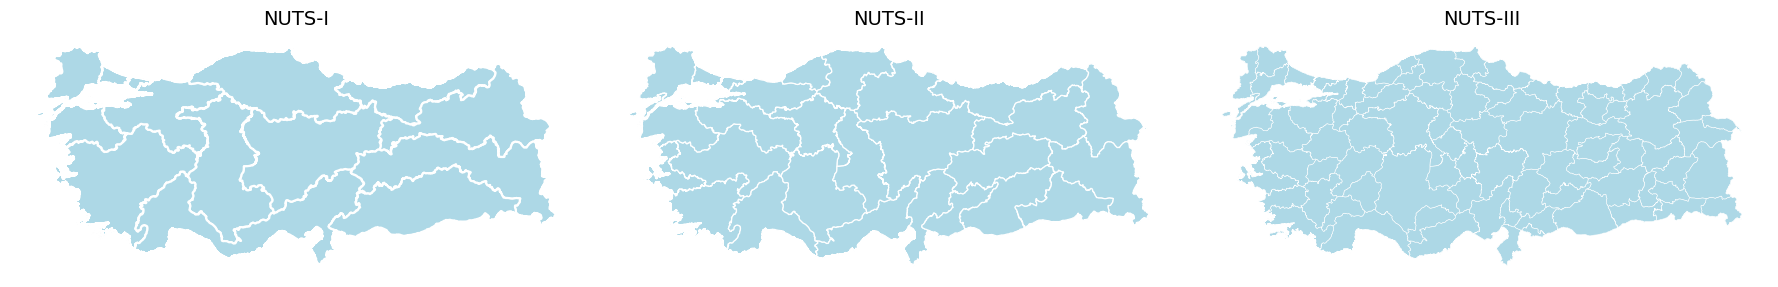

In [548]:
import matplotlib.pyplot as plt

# --- NUTS haritası için geçici kopya: İstanbul TR1'e geri alınıyor ---
# Analitik gdf'te İstanbul TR4'te kalıyor (Theil hesabı için).
# Bu haritada NUTS sınıflandırması doğru gösterilmeli.
gdf_map = gdf.copy()
gdf_map.loc[gdf_map['province'] == 'Istanbul', 'regionID'] = 'TR1'
gdf_map.loc[gdf_map['province'] == 'Istanbul', 'region']   = 'İstanbul'

# --- Dissolve to NUTS-I and NUTS-II boundaries ---
gdf_nuts1 = gdf_map.dissolve(by='regionID',    aggfunc='first').reset_index()
gdf_nuts2 = gdf_map.dissolve(by='subregionID', aggfunc='first').reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Panel 1: NUTS-I ───────────────────────────────────────────────────────────
gdf_nuts1.plot(
    ax=axes[0],
    color='lightblue',
    edgecolor='white',
    linewidth=1.6
)
axes[0].set_title('NUTS-I', fontsize=14, pad=8)
axes[0].axis('off')

# ── Panel 2: NUTS-II ──────────────────────────────────────────────────────────
gdf_nuts2.plot(
    ax=axes[1],
    color='lightblue',
    edgecolor='white',
    linewidth=0.9
)
axes[1].set_title('NUTS-II', fontsize=14, pad=8)
axes[1].axis('off')

# ── Panel 3: NUTS-III ─────────────────────────────────────────────────────────
gdf_map.plot(
    ax=axes[2],
    color='lightblue',
    edgecolor='white',
    linewidth=0.4
)
axes[2].set_title('NUTS-III', fontsize=14, pad=8)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('nuts_classification_maps.png', dpi=150, bbox_inches='tight')
plt.show()


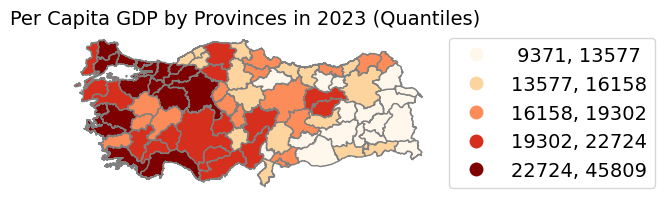

In [549]:


ax = gdf.plot(
    column="gdppc_2023",
    scheme="Quantiles",
    k=5,
    cmap="OrRd",
    legend=True,
    edgecolor="grey",
    legend_kwds={
        "loc": "center left",
        "bbox_to_anchor": (1, 0.5),
        "fmt": "{:.0f}",

    }
)

ax.set_axis_off()
ax.set_title("Per Capita GDP by Provinces in 2023 (Quantiles) ", fontsize=14)
plt.tight_layout()
plt.show()



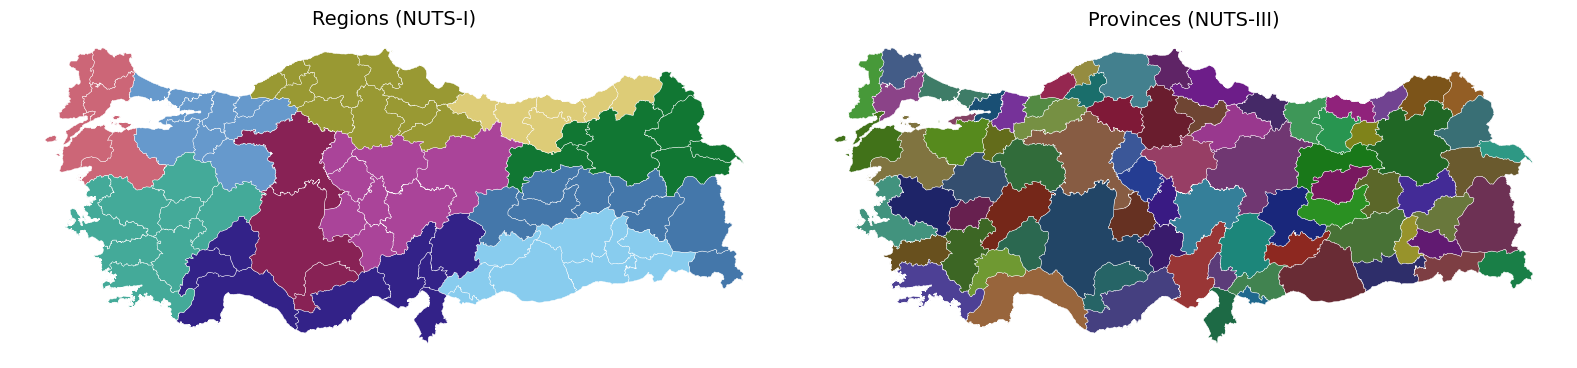

In [550]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# -----------------------------
# Regions (12) — aynı kalıyor
# -----------------------------
base_colors = [
    "#332288", "#88CCEE", "#44AA99", "#117733", "#999933",
    "#DDCC77", "#CC6677", "#882255", "#AA4499", "#6699CC",
    "#4477AA", "#66CCEE", "#228833", "#CCBB44", "#EE6677",
    "#AA3377", "#BBBBBB", "#774477", "#DDDDDD", "#FFA07A"
]

regions = gdf["region"].unique()
region_colors = {r: base_colors[i % len(base_colors)] for i, r in enumerate(regions)}
gdf["region_color"] = gdf["region"].map(region_colors)

# -----------------------------
# Provinces (81 unique colors)
# DISTINCT COLOR GENERATOR
# -----------------------------

provinces = sorted(gdf["province"].unique())   # sıralı olsun
n_provinces = len(provinces)

# high-distinct palette
# HSL tabanlı: hue + lightness + saturation varyasyonlu
province_palette = []
for i in range(n_provinces):
    h = (i / n_provinces)  # evenly spaced hue
    s = 0.65 + 0.15 * np.sin(i)   # subtle variation
    l = 0.50 + 0.10 * np.cos(i)   # subtle variation
    province_palette.append(mpl.colors.hsv_to_rgb((h, s, l)))

province_colors = {prov: province_palette[i] for i, prov in enumerate(provinces)}
gdf["province_color"] = gdf["province"].map(province_colors)

# -----------------------------
# Plot side-by-side maps
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# LEFT: Regions
gdf.plot(
    color=gdf["region_color"],
    edgecolor="white",
    linewidth=0.3,
    ax=axes[0]
)
axes[0].set_title("Regions (NUTS-I)", fontsize=14)
axes[0].axis("off")

# RIGHT: Provinces — fully distinct colors
gdf.plot(
    color=gdf["province_color"],
    edgecolor="white",
    linewidth=0.3,
    ax=axes[1]
)
axes[1].set_title("Provinces (NUTS-III)", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()




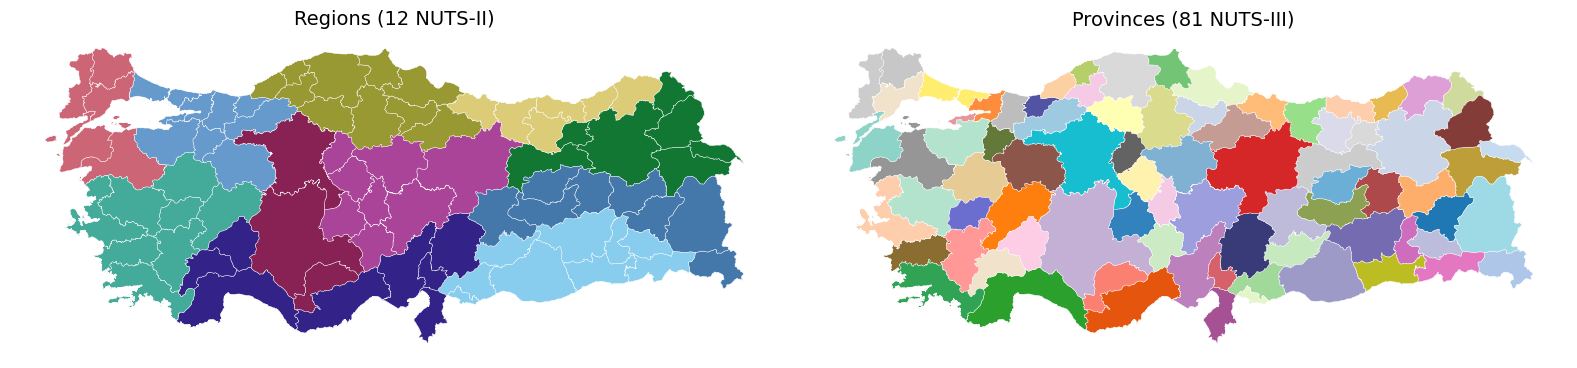

In [551]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# 1) REGIONS (12 bölge için hazır base palette)
# --------------------------------------------------------
base_colors = [
    "#332288", "#88CCEE", "#44AA99", "#117733", "#999933",
    "#DDCC77", "#CC6677", "#882255", "#AA4499", "#6699CC",
    "#4477AA", "#66CCEE"
]

regions = gdf["region"].unique()
region_colors = {r: base_colors[i % len(base_colors)] for i, r in enumerate(regions)}
gdf["region_color"] = gdf["region"].map(region_colors)

# --------------------------------------------------------
# 2) PROVINCES (81 benzersiz renk – eski palet mantığı)
# --------------------------------------------------------

provinces = gdf["province"].unique()
n = len(provinces)

# Büyük paletleri birleştir
palette = (
    [plt.cm.tab20(i) for i in range(20)] +
    [plt.cm.tab20b(i) for i in range(20)] +
    [plt.cm.tab20c(i) for i in range(20)] +
    [plt.cm.Set3(i) for i in range(12)]
)

# Yetmezse Pastel2 ekle
while len(palette) < n:
    palette += [plt.cm.Pastel2(i % 8) for i in range(8)]

# En önemli adım: renkleri karıştır (eski koddaki gibi)
rng = np.random.default_rng(42)
perm = rng.permutation(len(palette))[:n]
palette = [palette[i] for i in perm]

# Province → renk eşlemesi
province_colors = dict(zip(provinces, palette))
gdf["province_color"] = gdf["province"].map(province_colors)

# --------------------------------------------------------
# 3) YAN YANA HARİTALAR
# --------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# LEFT: Regions (12)
gdf.plot(
    color=gdf["region_color"],
    edgecolor="white",
    linewidth=0.3,
    ax=axes[0]
)
axes[0].set_title("Regions (12 NUTS-II)", fontsize=14)
axes[0].axis("off")

# RIGHT: Provinces (81 unique, eski stil renkler)
gdf.plot(
    color=gdf["province_color"],
    edgecolor="white",
    linewidth=0.3,
    ax=axes[1]
)
axes[1].set_title("Provinces (81 NUTS-III)", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()


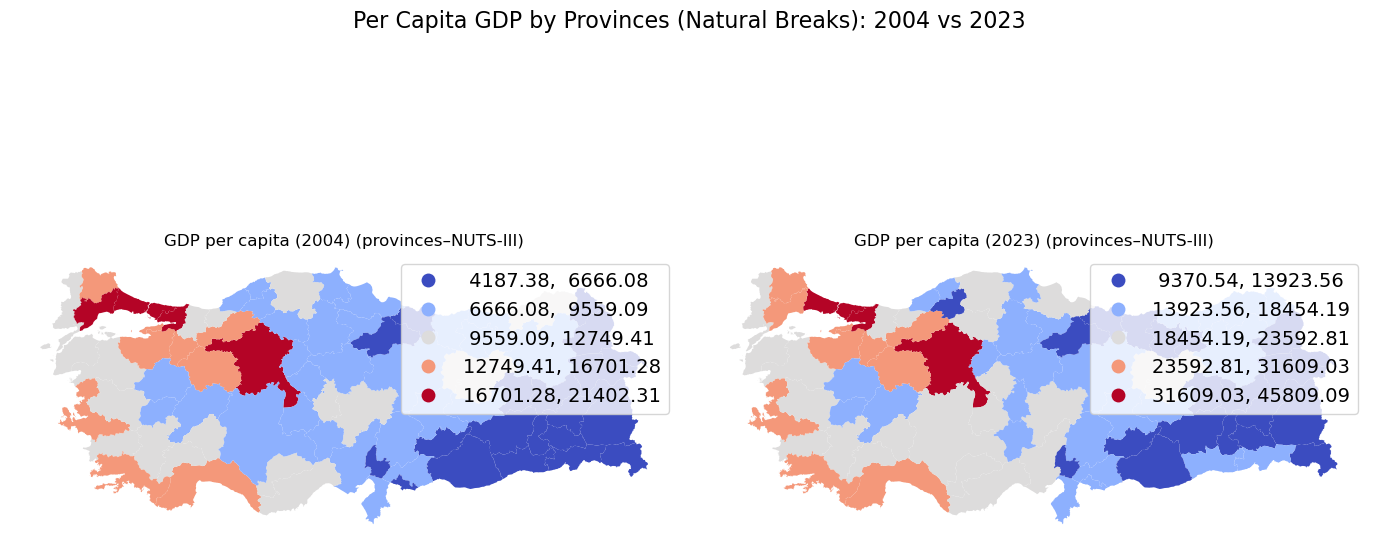

In [552]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 7))

gdf.plot(column="gdppc_2004", scheme="NaturalBreaks", k=5, cmap='coolwarm',
         legend=True, ax=axes[0])
axes[0].set_title('GDP per capita (2004) (provinces–NUTS-III)')
axes[0].axis("off")

gdf.plot(column="gdppc_2023", scheme="NaturalBreaks", k=5, cmap='coolwarm',
         legend=True, ax=axes[1])
axes[1].set_title('GDP per capita (2023) (provinces–NUTS-III)')
axes[1].axis("off")

plt.suptitle("Per Capita GDP by Provinces (Natural Breaks): 2004 vs 2023", fontsize=16, y=1.02)

plt.tight_layout()
plt.show()


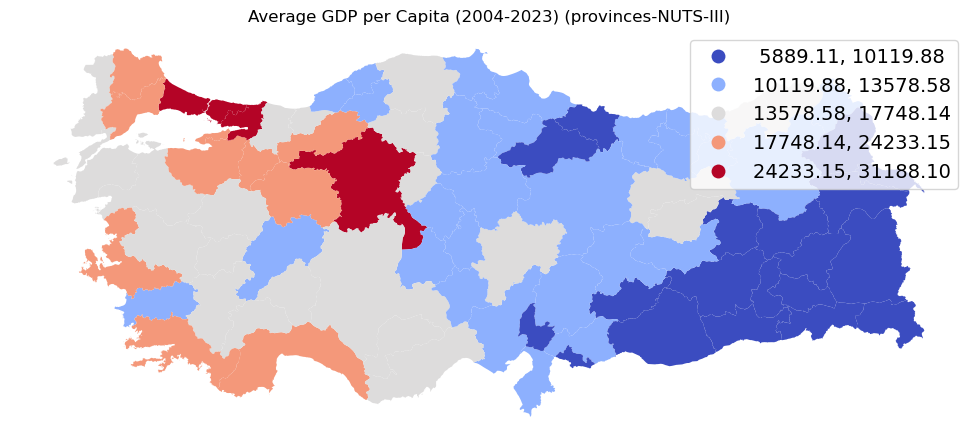

In [553]:
gdf['gdppc_mean'] = gdf[[col for col in gdf.columns if col.startswith('gdppc_')]].mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 7))
gdf.plot(column='gdppc_mean', scheme='NaturalBreaks', k=5, cmap='coolwarm',
         legend=True, ax=ax)
ax.set_title('Average GDP per Capita (2004-2023) (provinces-NUTS-III)')
ax.axis('off')
plt.tight_layout()
plt.show()

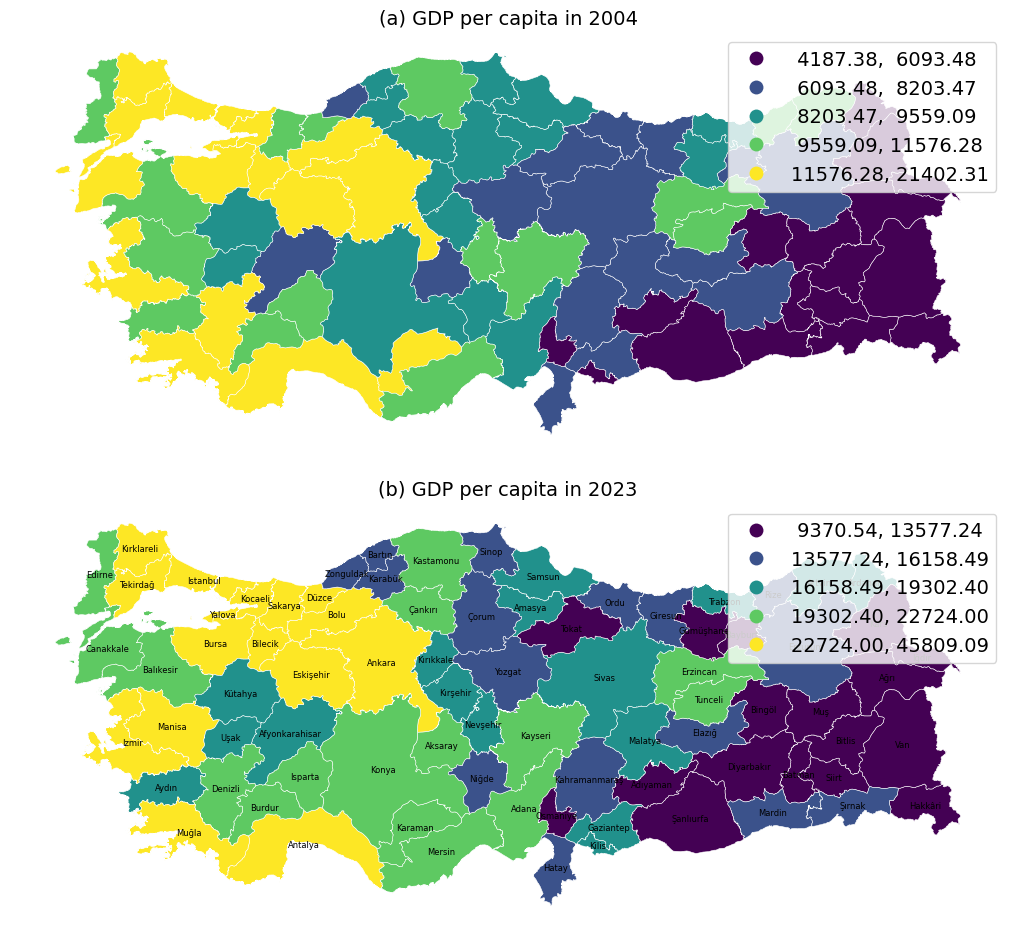

In [554]:
import geopandas as gpd
import matplotlib.pyplot as plt
import mapclassify

# -------------------------
# 1) Renk paleti (tutarlı)
# -------------------------
cmap_used = "viridis"

# -------------------------
# 2) ALT ALTA 2004/2023
# -------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 12))  # yükseklik daha kısa

# -------------------------
# PANEL (A) — 2004
# -------------------------
gdf.plot(
    column="gdppc_2004",
    cmap=cmap_used,
    scheme="quantiles",
    k=5,
    legend=True,
    edgecolor="white",
    linewidth=0.4,
    ax=axes[0]
)

axes[0].set_title("(a) GDP per capita in 2004", fontsize=14)
axes[0].axis("off")

# -------------------------
# PANEL (B) — 2023
# -------------------------
gdf.plot(
    column="gdppc_2023",
    cmap=cmap_used,
    scheme="quantiles",
    k=5,
    legend=True,
    edgecolor="white",
    linewidth=0.4,
    ax=axes[1]
)

axes[1].set_title("(b) GDP per capita in 2023", fontsize=14)

for idx, row in gdf.iterrows():
    if row.geometry is not None:
        centroid = row.geometry.centroid
        axes[1].text(
            centroid.x,
            centroid.y,
            str(row["shapeName_x"]),
            fontsize=6,
            ha="center",
            va="center",
            color="black"
        )

axes[1].axis("off")

# -------------------------
# PANEL BOŞLUĞUNU YOK ETME
# -------------------------
plt.tight_layout(pad=0.1)         # çok küçük padding
plt.subplots_adjust(hspace=-0.35) # NEGATİF → paneller neredeyse birleşir
fig.patch.set_facecolor("white")  # arka plan boşluğu görünmesin

# -------------------------
# SAVE FIGURE
# -------------------------
plt.savefig("gdp_maps_2004_2023_quantiles.png", dpi=150, bbox_inches="tight")
plt.show()











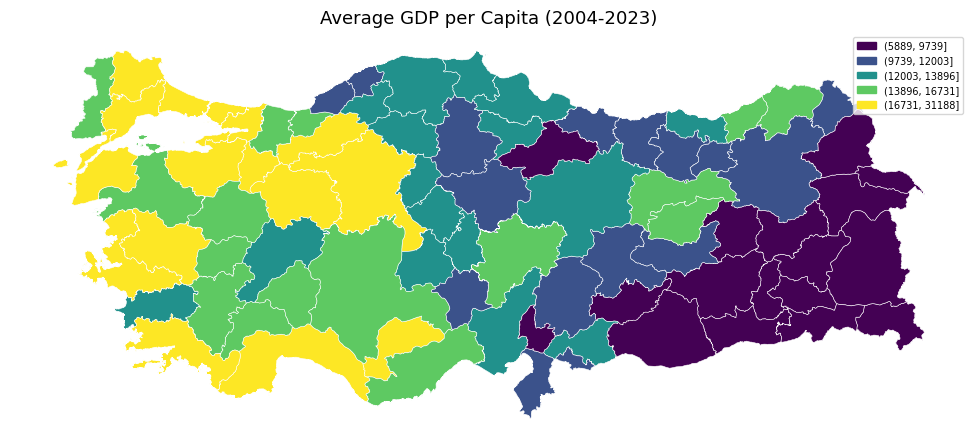

In [555]:
gdf['gdppc_mean'] = gdf[[col for col in gdf.columns if col.startswith('gdppc_')]].mean(axis=1)

cmap_used = "viridis"

fig, ax = plt.subplots(figsize=(10, 7))
gdf.plot(column='gdppc_mean', scheme='quantiles', k=5, cmap=cmap_used,
         legend=False, edgecolor='white', linewidth=0.4, ax=ax)

import mapclassify
import matplotlib.patches as mpatches
import matplotlib.cm as cm

classifier = mapclassify.Quantiles(gdf['gdppc_mean'], k=5)
colors = [cm.viridis(i/4) for i in range(5)]
bins = [gdf['gdppc_mean'].min()] + list(classifier.bins)
patches = []
for i in range(5):
    label = f'({bins[i]:.0f}, {bins[i+1]:.0f}]'
    patches.append(mpatches.Patch(color=colors[i], label=label))

ax.legend(handles=patches, loc='upper right', fontsize=7,
          frameon=True)

ax.set_title('Average GDP per Capita (2004-2023)', fontsize=13)
ax.axis('off')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('gdp_mean_map.png', dpi=150, bbox_inches='tight')
plt.show()

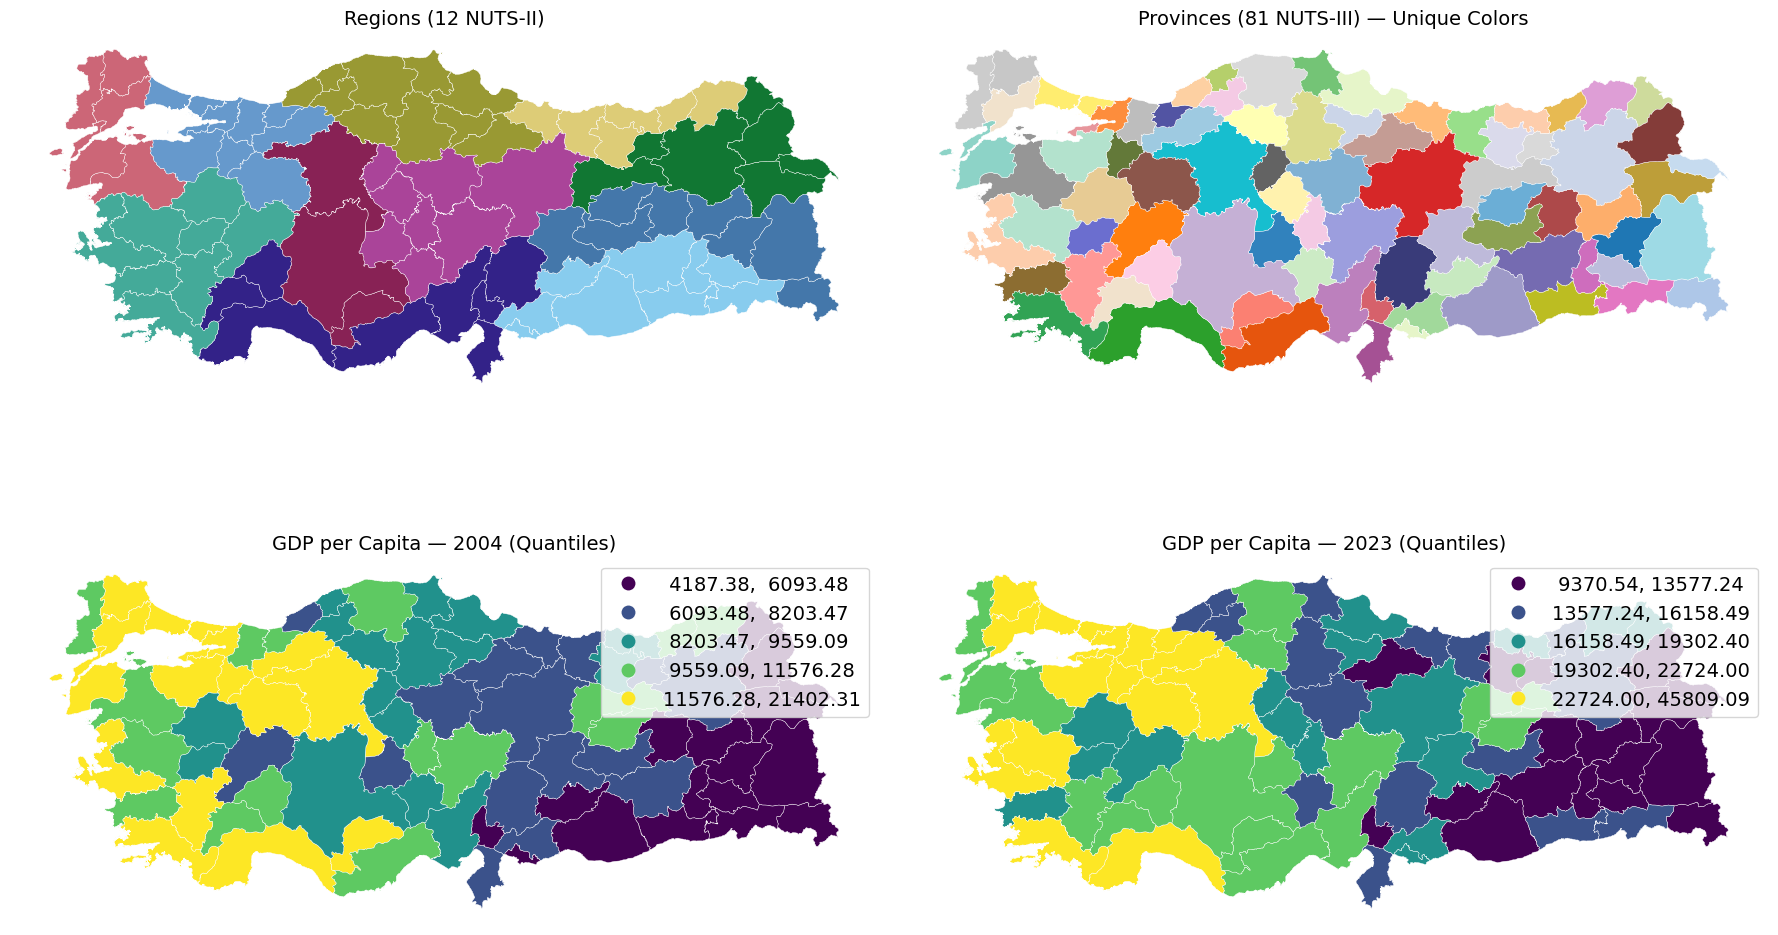

In [556]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import mapclassify

# --------------------------------------------------------
# 1) REGIONS (12 bölge için renkler – istediğin palette)
# --------------------------------------------------------
base_colors = [
    "#332288", "#88CCEE", "#44AA99", "#117733", "#999933",
    "#DDCC77", "#CC6677", "#882255", "#AA4499", "#6699CC",
    "#4477AA", "#66CCEE"
]

regions = gdf["region"].unique()
region_colors = {r: base_colors[i % len(base_colors)] for i, r in enumerate(regions)}
gdf["region_color"] = gdf["region"].map(region_colors)

# --------------------------------------------------------
# 2) PROVINCES (81 benzersiz renk – senin istediğin palette)
# --------------------------------------------------------
provinces = gdf["province"].unique()
n = len(provinces)

palette = (
    [plt.cm.tab20(i) for i in range(20)] +
    [plt.cm.tab20b(i) for i in range(20)] +
    [plt.cm.tab20c(i) for i in range(20)] +
    [plt.cm.Set3(i) for i in range(12)]
)

while len(palette) < n:
    palette += [plt.cm.Pastel2(i % 8) for i in range(8)]

rng = np.random.default_rng(42)   # sabit sıralama
perm = rng.permutation(len(palette))[:n]
palette = [palette[i] for i in perm]

province_colors = dict(zip(provinces, palette))
gdf["province_color"] = gdf["province"].map(province_colors)

# --------------------------------------------------------
# 3) 4’LÜ HARİTA (2x2 layout)
# --------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --------------------------------------------------------
# (1) Sol Üst — REGIONS (12)
# --------------------------------------------------------
gdf.plot(
    color=gdf["region_color"],
    edgecolor="white",
    linewidth=0.3,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Regions (12 NUTS-II)", fontsize=14)
axes[0, 0].axis("off")

# --------------------------------------------------------
# (2) Sağ Üst — PROVINCES (81 UNIQUE)
# --------------------------------------------------------
gdf.plot(
    color=gdf["province_color"],
    edgecolor="white",
    linewidth=0.3,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Provinces (81 NUTS-III) — Unique Colors", fontsize=14)
axes[0, 1].axis("off")

# --------------------------------------------------------
# (3) Sol Alt — GDP per Capita 2004 (QUANTILES)
# --------------------------------------------------------
gdf.plot(
    column="gdppc_2004",
    cmap="viridis",
    scheme="quantiles",
    k=5,
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    ax=axes[1, 0]
)
axes[1, 0].set_title("GDP per Capita — 2004 (Quantiles)", fontsize=14)
axes[1, 0].axis("off")

# --------------------------------------------------------
# (4) Sağ Alt — GDP per Capita 2023 (QUANTILES)
# --------------------------------------------------------
gdf.plot(
    column="gdppc_2023",
    cmap="viridis",
    scheme="quantiles",
    k=5,
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    ax=axes[1, 1]
)
axes[1, 1].set_title("GDP per Capita — 2023 (Quantiles)", fontsize=14)
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


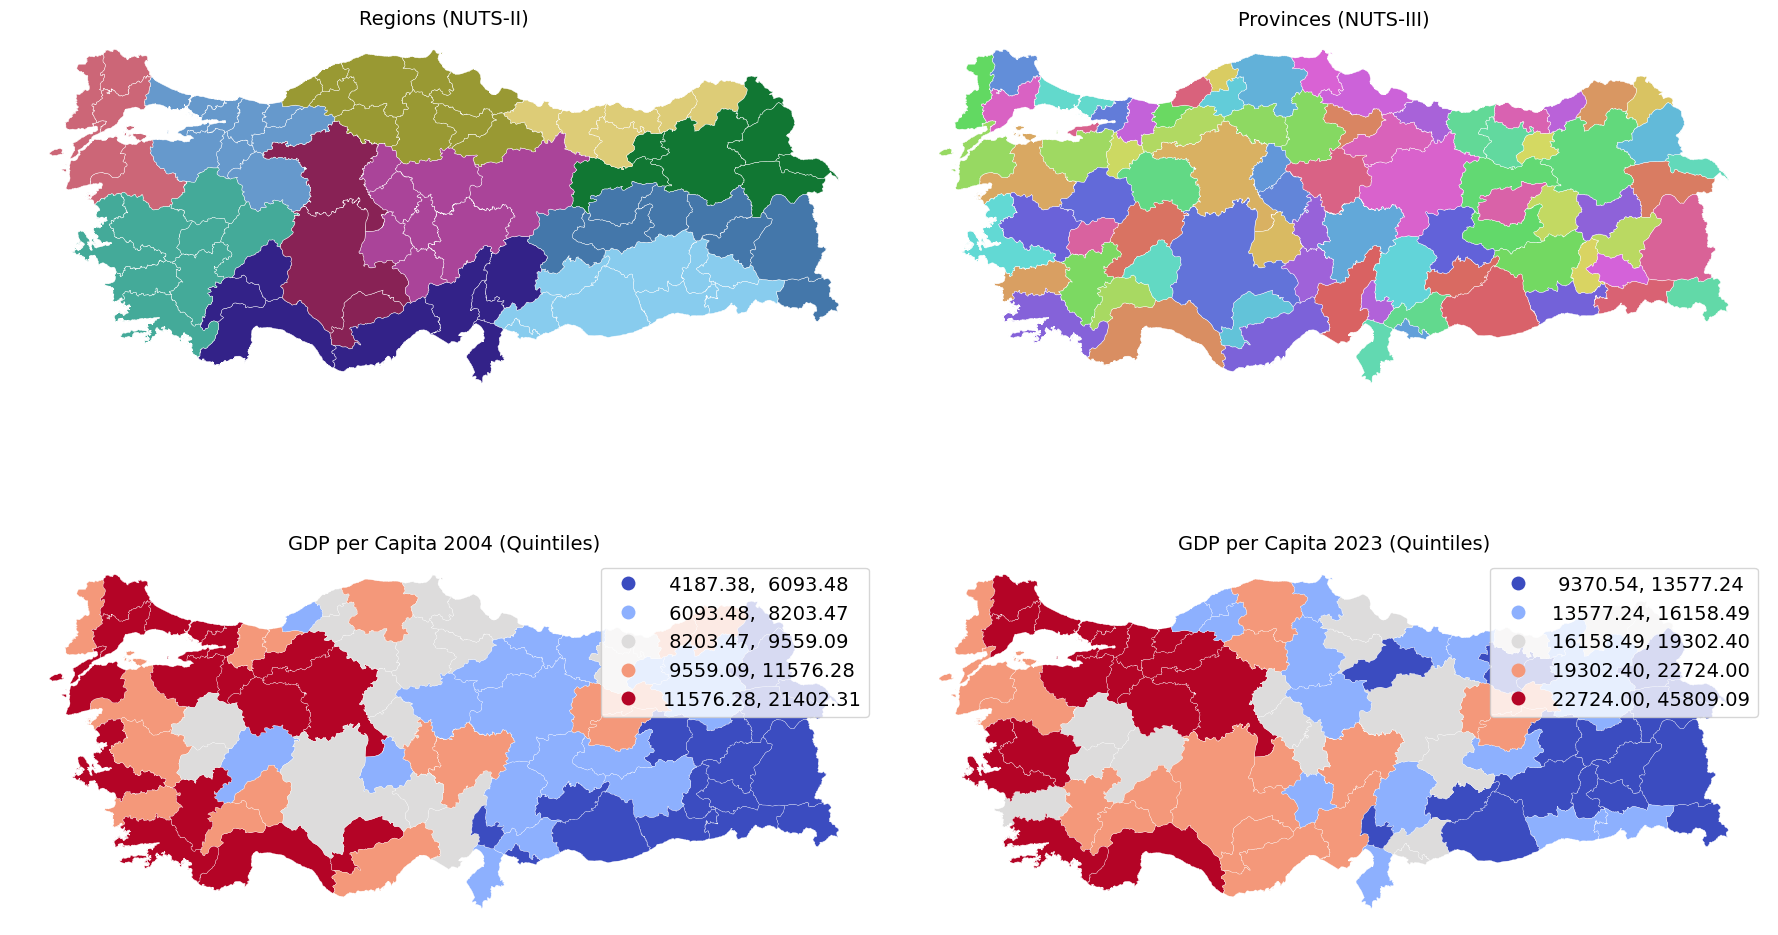

In [557]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# -----------------------------
# 1) COLOR SCHEMES
# -----------------------------
# 12 regions – categorical, professional palette
base_colors = [
    "#332288", "#88CCEE", "#44AA99", "#117733", "#999933",
    "#DDCC77", "#CC6677", "#882255", "#AA4499", "#6699CC",
    "#4477AA", "#66CCEE"
]

regions = gdf["region"].unique()
region_colors = {r: base_colors[i % len(base_colors)] for i, r in enumerate(regions)}
gdf["region_color"] = gdf["region"].map(region_colors)

# 81 provinces – unique color per province (HSV hues)
n_provinces = gdf["province"].nunique()
hues = np.linspace(0, 1, n_provinces, endpoint=False)
province_palette = [mpl.colors.hsv_to_rgb((h, 0.55, 0.85)) for h in hues]

provinces = gdf["province"].unique()
province_colors = {prov: province_palette[i] for i, prov in enumerate(provinces)}
gdf["province_color"] = gdf["province"].map(province_colors)

# -----------------------------
# 2) FIGURE SETUP (2x2)
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# -----------------------------
# PANEL 1 — REGIONS (12)
# -----------------------------
gdf.plot(
    color=gdf["region_color"],
    edgecolor="white",
    linewidth=0.3,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Regions (NUTS-II)", fontsize=14)
axes[0, 0].axis("off")

# -----------------------------
# PANEL 2 — PROVINCES (81 unique colors)
# -----------------------------
gdf.plot(
    color=gdf["province_color"],
    edgecolor="white",
    linewidth=0.3,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Provinces (NUTS-III)", fontsize=14)
axes[0, 1].axis("off")

# -----------------------------
# PANEL 3 — GDP Per Capita 2004 (Quintiles)
# -----------------------------
gdf.plot(
    column="gdppc_2004",
    scheme="quantiles",
    k=5,
    cmap="coolwarm",
    legend=True,
    edgecolor="white",
    linewidth=0.2,
    ax=axes[1, 0]
)
axes[1, 0].set_title("GDP per Capita 2004 (Quintiles)", fontsize=14)
axes[1, 0].axis("off")

# -----------------------------
# PANEL 4 — GDP Per Capita 2023 (Quintiles)
# -----------------------------
gdf.plot(
    column="gdppc_2023",
    scheme="quantiles",
    k=5,
    cmap="coolwarm",
    legend=True,
    edgecolor="white",
    linewidth=0.2,
    ax=axes[1, 1]
)
axes[1, 1].set_title("GDP per Capita 2023 (Quintiles)", fontsize=14)
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


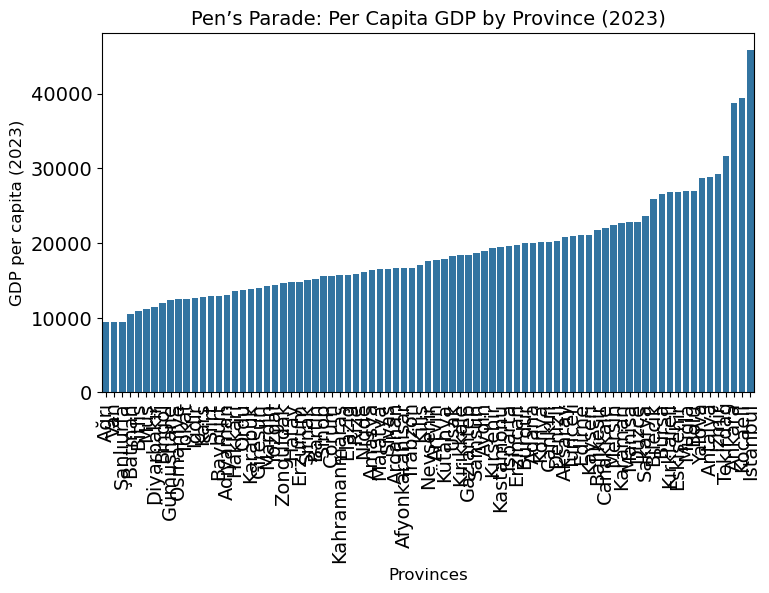

In [558]:
from inequality.pen import pen

f = pen(gdf, 'gdppc_2023', 'shapeName_x')

ax = f
ax.set_xlabel("Provinces", fontsize=12)
ax.set_ylabel("GDP per capita (2023)", fontsize=12)
ax.set_title("Pen’s Parade: Per Capita GDP by Province (2023)", fontsize=14)

plt.show()


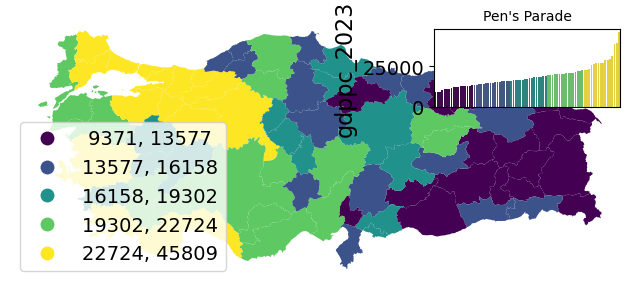

In [559]:
from inequality.pen import pengram

f = pengram(
    gdf,
    'gdppc_2023',
    "shapeName_x",
    xticks=False,
    leg_pos='lower left',
    fmt="{:.0f}"
)



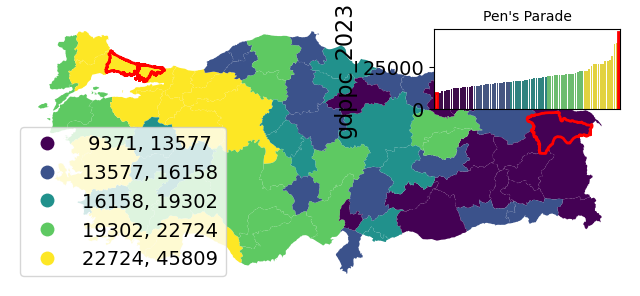

In [560]:
#provinces with the highest and lowest pc income

from inequality.pen import pengram
f = pengram(gdf,'gdppc_2023'
,
'shapeName_x', leg_pos='lower left'
,
fmt="{:.0f}"
,
xticks=False,
query=['Ağrı'
,
'Istanbul'])

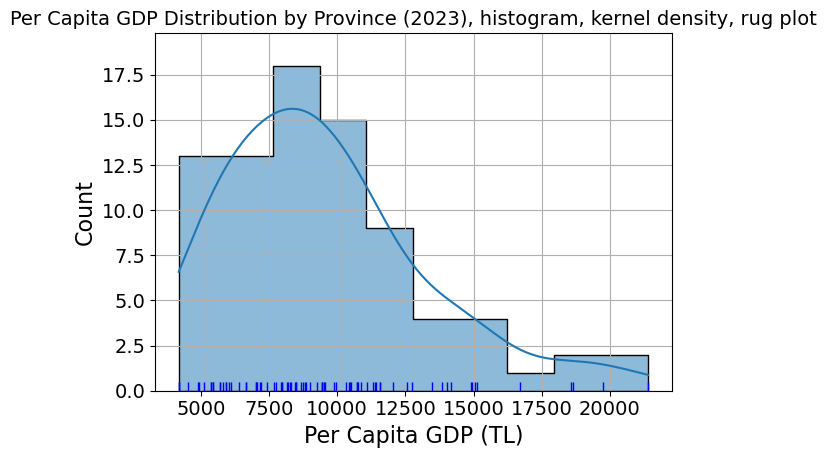

In [561]:


years = range(2004, 2023, 20)
yvars = [f'gdppc_{year}' for year in years]

sns.histplot(gdf[yvars[-1]], kde=True, element="step", bins=10, edgecolor="black")
sns.rugplot(gdf[yvars[-1]], color='blue')

plt.title("Per Capita GDP Distribution by Province (2023), histogram, kernel density, rug plot",  fontsize=14)
plt.xlabel("Per Capita GDP (TL)")
plt.ylabel("Count")
plt.tight_layout()
plt.grid(True)
plt.show()


# Lorenz curves

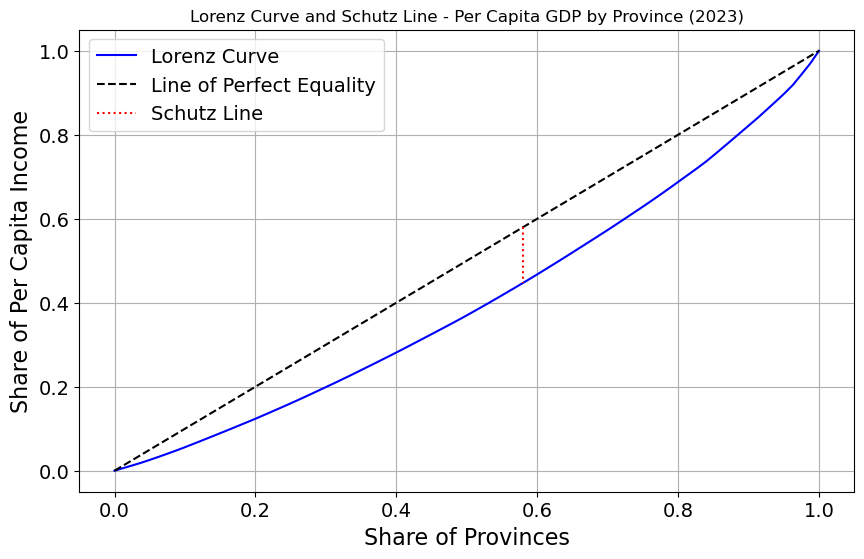

In [563]:

from inequality.schutz import Schutz

s = Schutz(gdf, 'gdppc_2023')
s.plot(
    xlabel='Share of Provinces',
    ylabel='Share of Per Capita Income',
    title='Lorenz Curve and Schutz Line - Per Capita GDP by Province (2023)',
)




In [564]:
years = range(2004, 2024)

yvars = [f'gdppc_{year}' for year in years]
ginis = [ineq.gini.Gini(gdf[yvar]).g for yvar in yvars]
res_df = pd.DataFrame(data=ginis, columns=['Gini'], index=years)
cv = gdf[yvars].std() / gdf[yvars].mean()
res_df['CV'] = cv.values
s = [ineq.schutz.Schutz(gdf, yvar).distance for yvar in yvars]
res_df['Schutz'] = s
res_df['Gini_rank'] = res_df['Gini'].rank()
res_df['CV_rank'] = res_df['CV'].rank()
res_df['Schutz_rank'] = res_df['Schutz'].rank()
res_df

/opt/anaconda3/lib/python3.12/site-packages/inequality/gini.py:43: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  x = x.ravel()  # ensure shape is (n,)


,Gini,CV,Schutz,Gini_rank,CV_rank,Schutz_rank
2004,0.210747,0.389937,0.149743,17.0,17.0,17.0
2005,0.209812,0.389647,0.148559,16.0,16.0,16.0
2006,0.213393,0.396596,0.152415,18.0,18.0,18.0
2007,0.216528,0.404066,0.154538,20.0,20.0,20.0
2008,0.215672,0.399154,0.153317,19.0,19.0,19.0
2009,0.205380,0.379037,0.145634,15.0,15.0,15.0
2010,0.193278,0.359071,0.135723,11.0,7.0,10.0
2011,0.198580,0.369233,0.139256,14.0,14.0,14.0
2012,0.193978,0.360529,0.136714,13.0,11.0,12.0
2013,0.192490,0.360910,0.135279,10.0,12.0,8.0


In [565]:
#yorum: 2020 yılı, tüm göstergelere göre en düşük eşitsizlik yılı.
#2007–2009, açık ara en yüksek eşitsizlik dönemi.
#2021–2023 arası, görünürde genel eşitsizlik çok artmasa da, CV'nin yükselmesi, zengin bölgelerle
#diğerleri arasındaki farkın büyüdüğüne işaret eder mi?


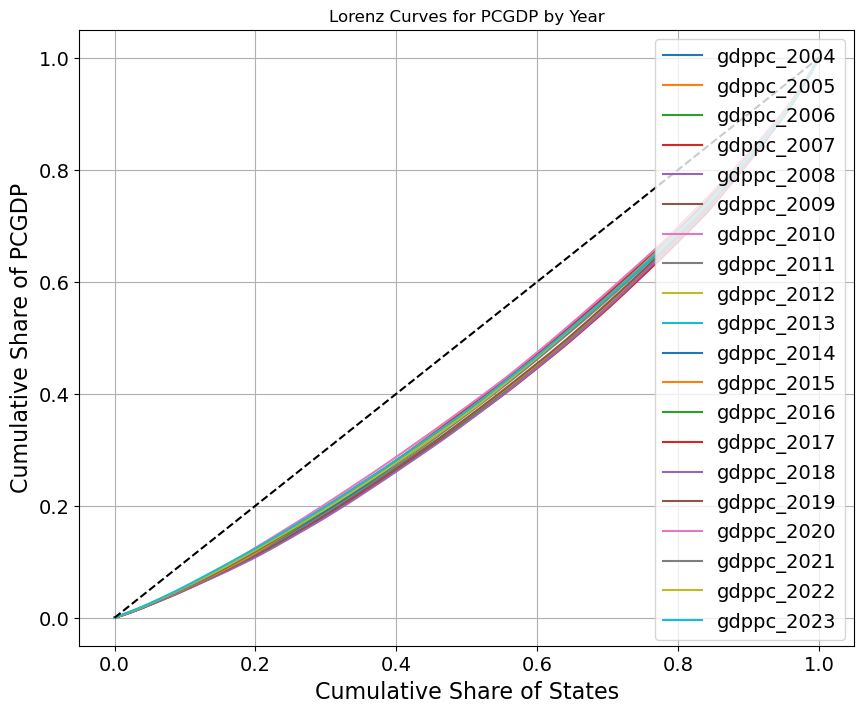

In [566]:
# Plot Lorenz Curves for each year
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import cumfreq

def lorenz_curve(incomes):
    sorted_incomes = np.sort(incomes)
    cumulative_incomes = np.cumsum(sorted_incomes)
    normalized = cumulative_incomes / cumulative_incomes[-1]
    lorenz_curve = np.insert(normalized, 0, 0)
    n = len(incomes)
    x = np.linspace(0.0, 1.0, n + 1)
    return x, lorenz_curve

plt.figure(figsize=(10, 8))

for yvar in yvars:
    incomes = gdf[yvar].values
    x, y = lorenz_curve(incomes)
    plt.plot(x, y, label=yvar)

# Plotting the line of equality
plt.plot([0, 1], [0, 1], color='black', linestyle='--')

# Adding titles and labels
plt.title('Lorenz Curves for PCGDP by Year')
plt.xlabel('Cumulative Share of States')
plt.ylabel('Cumulative Share of PCGDP')
plt.legend()
plt.grid(True)
plt.show()



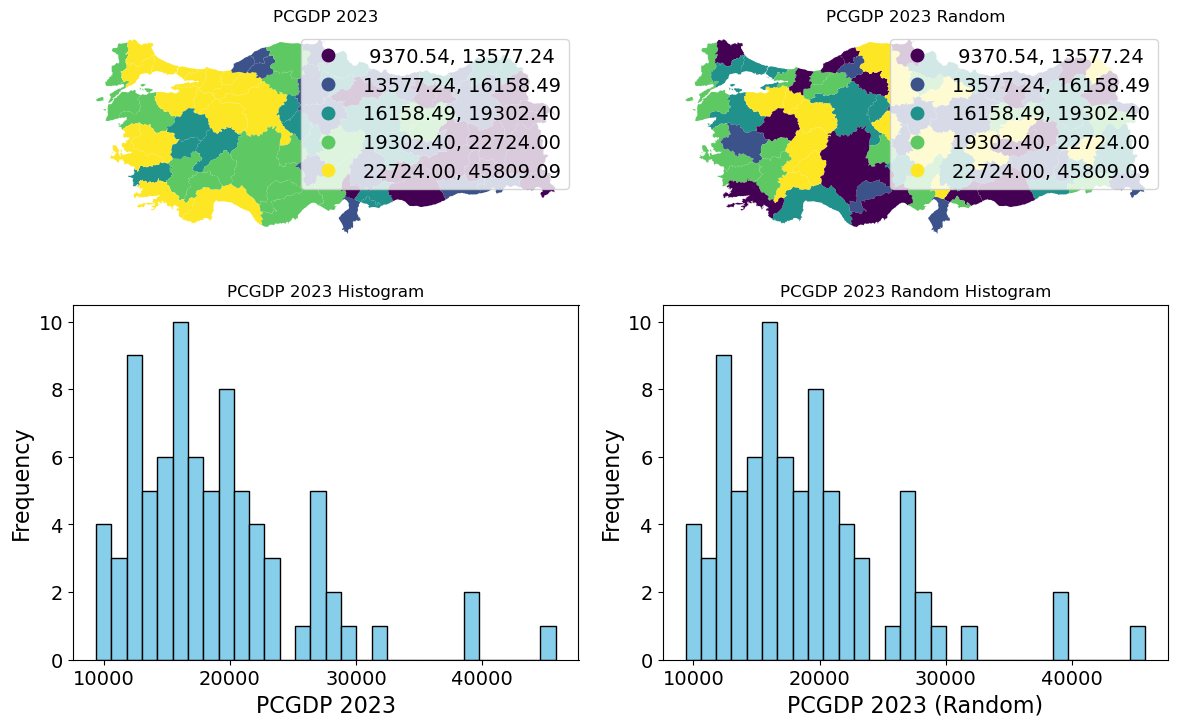

In [567]:


# Create a random permutation column for 2023 data
gdf['gdppc_2023r'] = np.random.permutation(gdf['gdppc_2023'])

# Set up a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Choropleth for original 2023 data
gdf.plot(column='gdppc_2023', ax=axs[0, 0], scheme='quantiles', cmap='viridis', legend=True)
axs[0, 0].set_title('PCGDP 2023')
axs[0, 0].axis('off')

# Choropleth for randomly permuted data
gdf.plot(column='gdppc_2023r', ax=axs[0, 1], scheme='quantiles', cmap='viridis', legend=True)
axs[0, 1].set_title('PCGDP 2023 Random')
axs[0, 1].axis('off')

# Histogram for original 2023 data
axs[1, 0].hist(gdf['gdppc_2023'], bins=30, color='skyblue', edgecolor='black')
axs[1, 0].set_title('PCGDP 2023 Histogram')
axs[1, 0].set_xlabel('PCGDP 2023')
axs[1, 0].set_ylabel('Frequency')

# Histogram for randomly permuted data
axs[1, 1].hist(gdf['gdppc_2023r'], bins=30, color='skyblue', edgecolor='black')
axs[1, 1].set_title('PCGDP 2023 Random Histogram')
axs[1, 1].set_xlabel('PCGDP 2023 (Random)')
axs[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


# Regional Inequality Decomposition

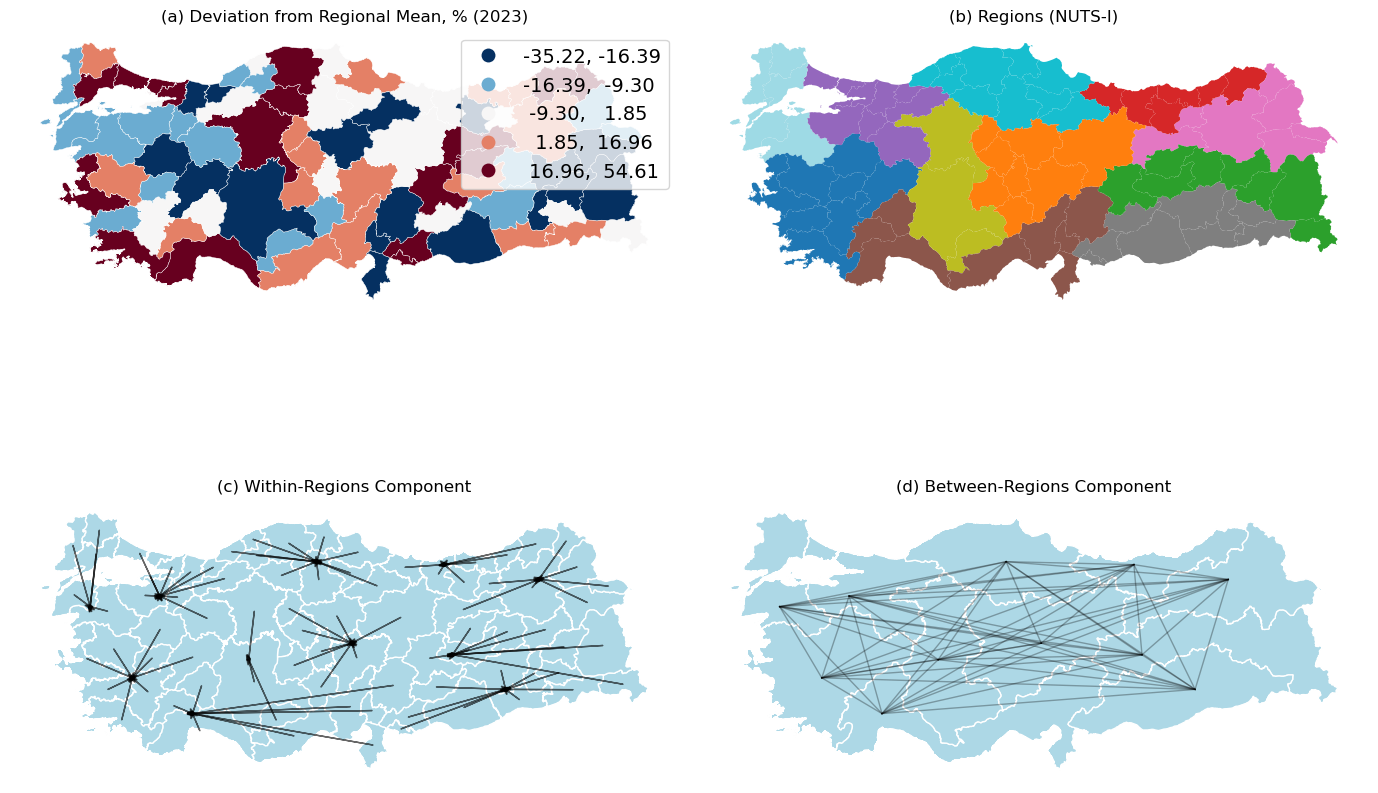

In [569]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Project to metric CRS (important for proper distances)
gdf_proj = gdf.to_crs(epsg=32636)

# Step 2: Compute province centroids
gdf_proj['centroid'] = gdf_proj.geometry.centroid

# Step 3: Dissolve by region (keep numeric columns + geometry)
numeric_cols = gdf_proj.select_dtypes(include='number').columns.tolist()
cols_to_keep = ['region', 'geometry'] + numeric_cols
region_means = gdf_proj[cols_to_keep].dissolve(by='region', aggfunc='mean')
region_means['centroid'] = region_means.geometry.representative_point()

# Step 4: Setup plot grid
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Panel 1: Within-Region Deviation (% deviation from regional mean, 2023)
# Replaces the raw GDP 2023 map to avoid repetition with Figure 3.
# This panel directly illustrates the within-region component of the Theil decomposition.
regional_mean_2023 = gdf.groupby('regionID')['gdppc_2023'].transform('mean')
gdf_plot = gdf.copy()
gdf_plot['within_dev'] = (gdf['gdppc_2023'] - regional_mean_2023) / regional_mean_2023 * 100
gdf_plot.plot(
    column='within_dev',
    cmap='RdBu_r',
    scheme='quantiles',
    k=5,
    legend=True,
    edgecolor='white',
    linewidth=0.3,
    ax=axs[0, 0]
)
axs[0, 0].set_title('(a) Deviation from Regional Mean, % (2023)')
axs[0, 0].axis('off')

# Panel 2: Regions (NUTS-I)
gdf.plot(column='region', cmap='tab20', legend=False, ax=axs[0, 1])
axs[0, 1].set_title('(b) Regions (NUTS-I)')
axs[0, 1].axis('off')

# Panel 3: Within-Regions Component
gdf_proj.plot(color='lightblue', edgecolor='white', ax=axs[1, 0])
axs[1, 0].set_title('(c) Within-Regions Component')
for idx, row in gdf_proj.iterrows():
    p_center = row['centroid']
    r_center = region_means.loc[row['region'], 'centroid']
    axs[1, 0].arrow(p_center.x, p_center.y,
                   r_center.x - p_center.x,
                   r_center.y - p_center.y,
                   color='black', head_width=10000, alpha=0.6)
axs[1, 0].axis('off')

# Panel 4: Between-Regions Component (simplified)
region_means.plot(color='lightblue', edgecolor='white', ax=axs[1, 1])
axs[1, 1].set_title('(d) Between-Regions Component')

region_centroids = region_means['centroid']
for i, centroid_i in region_centroids.items():
    for j, centroid_j in region_centroids.items():
        if i < j:
            axs[1, 1].plot([centroid_i.x, centroid_j.x],
                          [centroid_i.y, centroid_j.y],
                          color='black', linewidth=1, alpha=0.3)

axs[1, 1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("within_between_maps_revised.png", dpi=150, bbox_inches='tight')
plt.show()


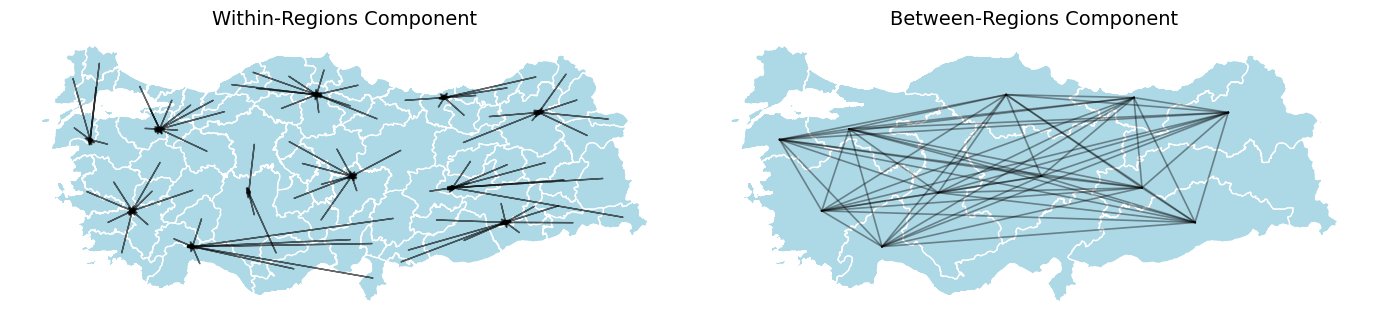

In [570]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Project to metric CRS (important for proper distances)
gdf_proj = gdf.to_crs(epsg=32636)

# Step 2: Compute province centroids
gdf_proj['centroid'] = gdf_proj.geometry.centroid

# Step 3: Dissolve by region (numeric cols + geometry)
numeric_cols = gdf_proj.select_dtypes(include='number').columns.tolist()
cols_to_keep = ['region', 'geometry'] + numeric_cols
region_means = gdf_proj[cols_to_keep].dissolve(by='region', aggfunc='mean')
region_means['centroid'] = region_means.geometry.representative_point()

# -------------------------------
#   FIGURE: WITHIN & BETWEEN
# -------------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# ------------------------------------
# PANEL 1: Within-Regions Component
# ------------------------------------
gdf_proj.plot(color='lightblue', edgecolor='white', ax=axs[0])
axs[0].set_title('Within-Regions Component', fontsize=14)

# arrows from each province → regional centroid
for _, row in gdf_proj.iterrows():
    p_center = row['centroid']
    r_center = region_means.loc[row['region'], 'centroid']
    axs[0].arrow(
        p_center.x, p_center.y,
        r_center.x - p_center.x,
        r_center.y - p_center.y,
        color='black', head_width=10000, alpha=0.6
    )

axs[0].axis('off')

# ------------------------------------
# PANEL 2: Between-Regions Component
# ------------------------------------
region_means.plot(color='lightblue', edgecolor='white', ax=axs[1])
axs[1].set_title('Between-Regions Component', fontsize=14)

# connect region centroids with lines
centroids = region_means['centroid']
for i, ci in centroids.items():
    for j, cj in centroids.items():
        if str(i) < str(j):
            axs[1].plot(
                [ci.x, cj.x],
                [ci.y, cj.y],
                color='black', linewidth=1.2, alpha=0.4
            )

axs[1].axis('off')



plt.tight_layout(rect=[0, 0, 1, 0.94])

# -------------------------------
# SAVE HIGH RES PNG
# -------------------------------
plt.savefig("within_between_maps_revised", dpi=600, bbox_inches='tight')

plt.show()


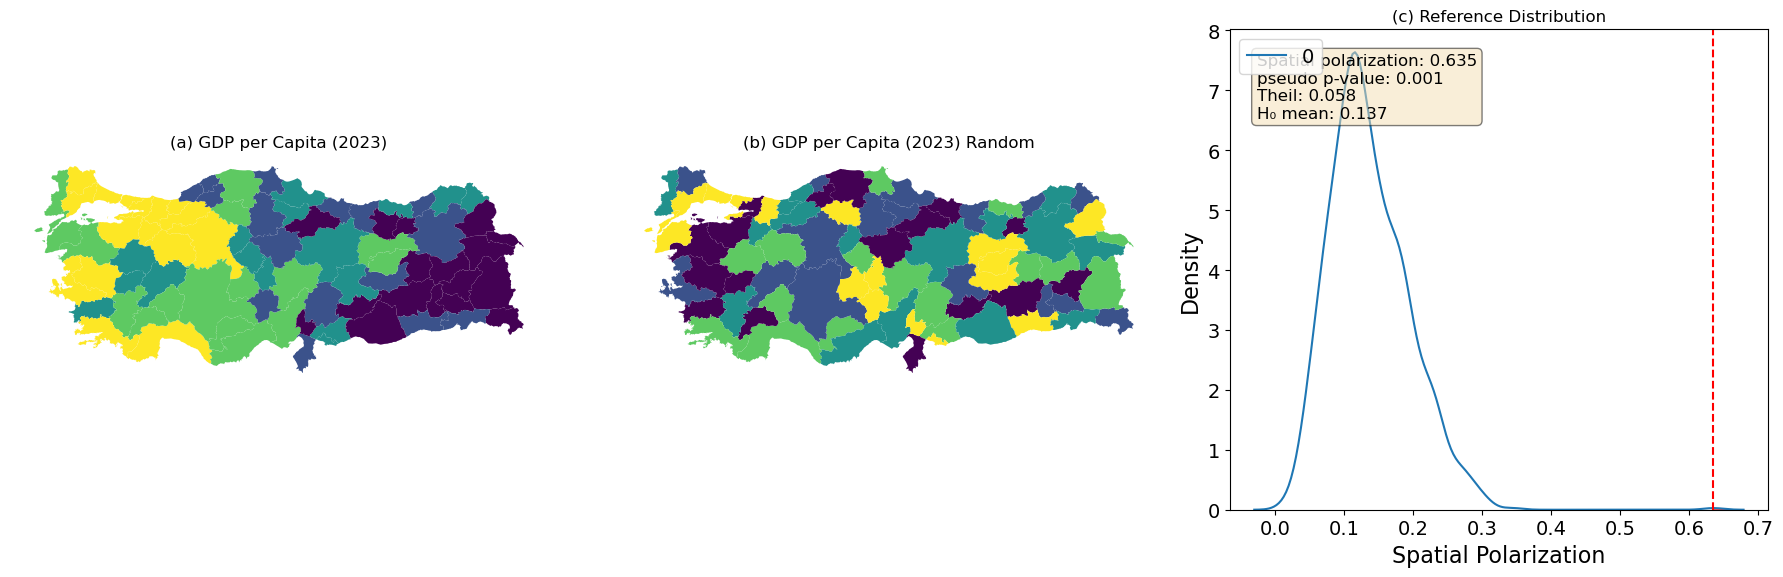

In [571]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from inequality.theil import TheilDSim

# --- Font ayarları ---
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

np.random.seed(12345)

# --- Compute Theil + spatial polarization ---
income = gdf['gdppc_2023']
regimes = gdf['regionID']
res = TheilDSim(income, regimes, 999)

# --- Figure: 1x3 layout ---
# Panel (a): observed 2023 map   |  Panel (b): one random permutation  |  Panel (c): reference distribution
# The 2023 GDP map appears here once; Figure 5 cross-references this panel.
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# --- Panel (a): Actual 2023 GDP ---
gdf.plot(column='gdppc_2023', ax=axs[0], scheme='quantiles', cmap='viridis')
axs[0].set_title('(a) GDP per Capita (2023)')
axs[0].axis('off')

# --- Panel (b): One random permutation ---
gdf['gdppc_2023r'] = np.random.permutation(gdf['gdppc_2023'].values)
gdf.plot(column='gdppc_2023r', ax=axs[1], scheme='quantiles', cmap='viridis')
axs[1].set_title('(b) GDP per Capita (2023) Random')
axs[1].axis('off')

# --- Panel (c): KDE of spatial polarization realizations ---
realizations = np.array([t.bg / t.T for t in res.results])
observed_pol = res.bg[0][0] / res.T

sns.kdeplot(realizations, fill=False, color='blue', ax=axs[2])
x, y = axs[2].get_lines()[0].get_data()
axs[2].fill_between(x, y, where=(x >= observed_pol), interpolate=True, color='red', alpha=0.5)
axs[2].axvline(x=observed_pol, color='red', linestyle='--')
axs[2].set_xlabel("Spatial Polarization")
axs[2].set_ylabel("Density")
axs[2].set_title('(c) Reference Distribution')

# --- Summary stats box inside panel (c) ---
summary_text = (
    f"Spatial polarization: {observed_pol:.3f}\n"
    f"pseudo p-value: {res.bg_pvalue[0]:.3f}\n"
    f"Theil: {res.T:.3f}\n"
    f"H\u2080 mean: {realizations.mean():.3f}"
)
axs[2].text(
    0.05, 0.95, summary_text,
    fontsize=12, ha='left', va='top',
    transform=axs[2].transAxes,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

plt.tight_layout()
plt.savefig("spatial_polarization.png", dpi=150, bbox_inches='tight')
plt.show()


The overall level of regional inequality is 0.058.
The between-region component accounts for 0.037, while the within-region component stands at 0.021.
This implies that approximately 64 percent of the total provincial income inequality in Türkiye arises from disparities between regions, whereas 36 percent stems from inequality within regions—that is, differences among provinces belonging to the same region.









/opt/anaconda3/lib/python3.12/site-packages/splot/_viz_libpysal_mpl.py:121: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids_shp = gdf.centroid.values
/opt/anaconda3/lib/python3.12/site-packages/splot/_viz_libpysal_mpl.py:164: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf.centroid.plot(ax=ax, **node_kws)


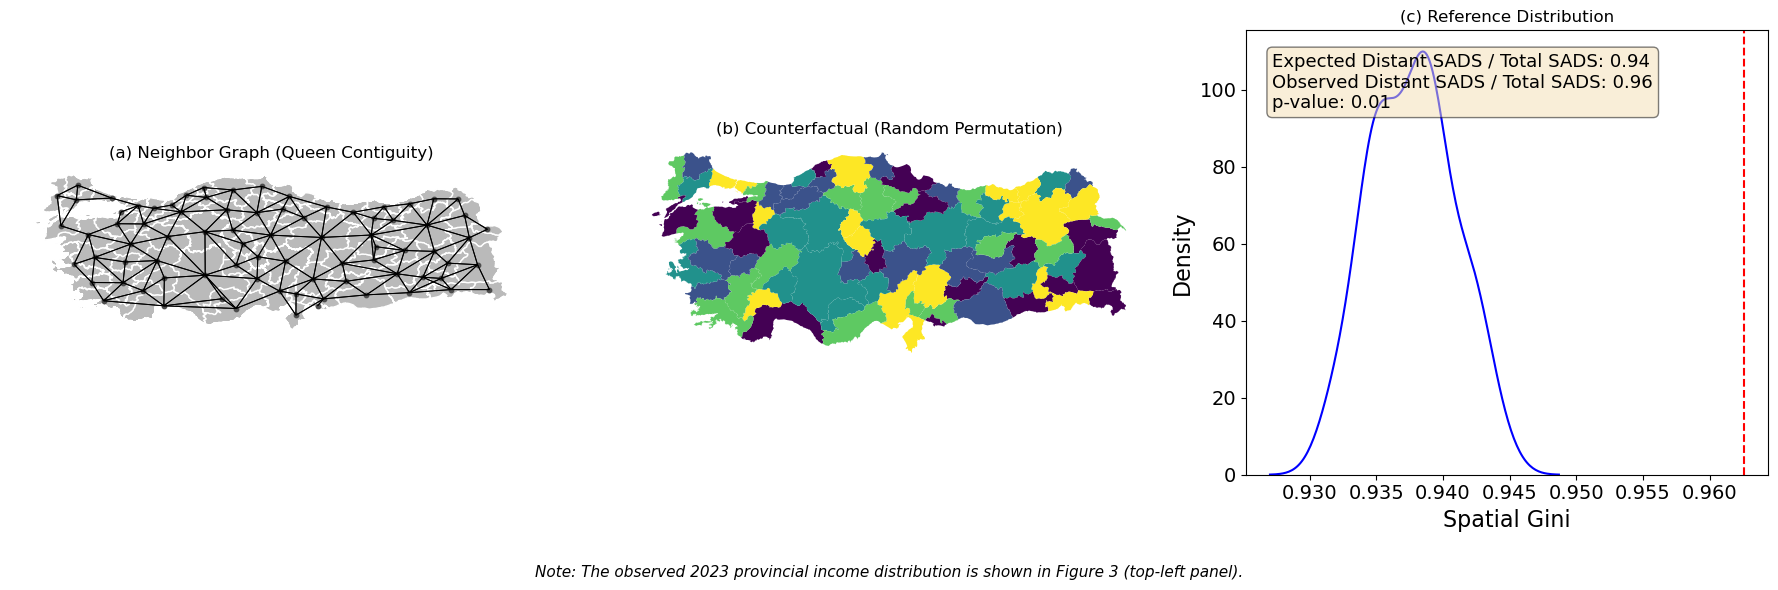

Expected Distant SADS / Total SADS: 0.94
Observed Distant SADS / Total SADS: 0.96
p-value: 0.01


In [573]:
from inequality.gini import Gini_Spatial
import libpysal
from splot.libpysal import plot_spatial_weights
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# --- Font settings ---
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# --- Random seed ---
np.random.seed(12345)

# --- Queen contiguity weight matrix ---
wq = libpysal.weights.Queen.from_dataframe(gdf, use_index=False)
wq.transform = 'B'

# --- Spatial Gini computation ---
gs = Gini_Spatial(gdf['gdppc_2023'], wq)
adsum = gs.dtotal
realizations = gs.wcgp / adsum
observed = gs.wcg / adsum

# --- 3-panel layout (GDP 2023 map omitted; see Figure 3 for observed distribution) ---
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Queen contiguity graph
gdf.plot(ax=axs[0], color='lightblue', edgecolor='white')
plot_spatial_weights(wq, gdf, ax=axs[0], edge_kws=dict(color='black', linewidth=0.5))
axs[0].set_title('(a) Neighbor Graph (Queen Contiguity)')
axs[0].axis('off')

# Panel 2: Counterfactual (random permutation)
gdf['gdppc_2023r'] = np.random.permutation(gdf['gdppc_2023'].values)
gdf.plot(column='gdppc_2023r', ax=axs[1], scheme='quantiles', cmap='viridis')
axs[1].set_title('(b) Counterfactual (Random Permutation)')
axs[1].axis('off')

# Panel 3: Reference distribution (KDE)
sns.kdeplot(realizations, fill=False, color='blue', ax=axs[2])
x, y = axs[2].lines[0].get_data()
axs[2].fill_between(x, y, where=(x >= observed), interpolate=True, color='red', alpha=0.5)
axs[2].axvline(x=observed, color='red', linestyle='--')
axs[2].set_xlabel("Spatial Gini")
axs[2].set_ylabel("Density")
axs[2].set_title('(c) Reference Distribution')

summary_text = (
    f"Expected Distant SADS / Total SADS: {gs.e_wcg / adsum:.2f}\n"
    f"Observed Distant SADS / Total SADS: {gs.wcg / adsum:.2f}\n"
    f"p-value: {gs.p_sim:.2f}"
)
axs[2].text(
    0.05, 0.95, summary_text,
    fontsize=13, ha='left', va='top',
    transform=axs[2].transAxes,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

fig.suptitle(
    'Note: The observed 2023 provincial income distribution is shown in Figure 3 (top-left panel).',
    fontsize=11, style='italic', y=-0.02
)

plt.tight_layout()
plt.savefig("spatial_gini.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Expected Distant SADS / Total SADS: {gs.e_wcg / adsum:.2f}")
print(f"Observed Distant SADS / Total SADS: {gs.wcg / adsum:.2f}")
print(f"p-value: {gs.p_sim:.2f}")


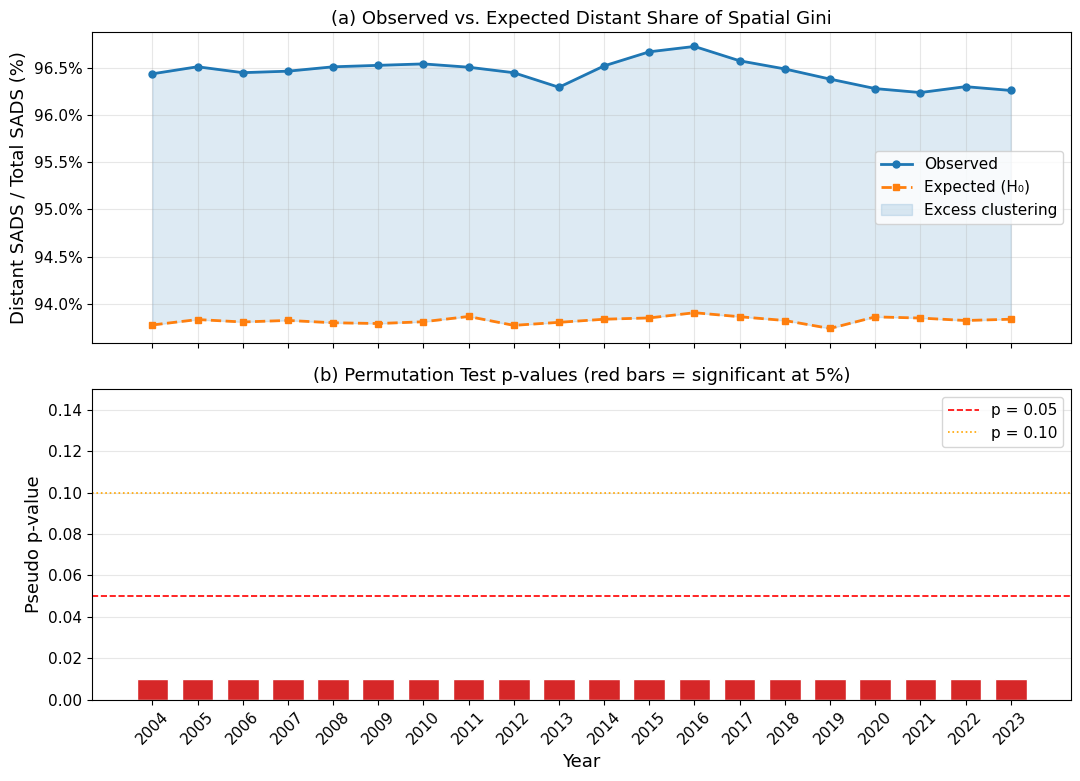


Appendix Table: Spatial Gini Decomposition — All Years
  Year   Observed (%)   Expected (%)  Excess (pp)   p-value   Sig
----------------------------------------------------------------------
  2004          96.43          93.78        +2.66     0.010   ***
  2005          96.51          93.83        +2.67     0.010   ***
  2006          96.45          93.81        +2.64     0.010   ***
  2007          96.46          93.83        +2.64     0.010   ***
  2008          96.51          93.80        +2.71     0.010   ***
  2009          96.52          93.79        +2.73     0.010   ***
  2010          96.54          93.81        +2.73     0.010   ***
  2011          96.50          93.87        +2.64     0.010   ***
  2012          96.45          93.77        +2.67     0.010   ***
  2013          96.29          93.81        +2.49     0.010   ***
  2014          96.52          93.84        +2.68     0.010   ***
  2015          96.67          93.85        +2.82     0.010   ***
  2016         

In [574]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from inequality.gini import Gini_Spatial
import libpysal

# --------------------------------------------------------
# Appendix: Spatial Gini Decomposition — All Years (2004-2023)
# --------------------------------------------------------
# For each year we compute:
#   - Observed distant SADS share  (gs.wcg  / gs.dtotal)
#   - Expected distant SADS share  (gs.e_wcg / gs.dtotal)
#   - Pseudo p-value               (gs.p_sim)
# A share > expected means that distant (non-neighboring) province pairs
# account for a LARGER share of total income differences than random,
# i.e., neighboring provinces are more similar than chance — spatial clustering.
# --------------------------------------------------------

np.random.seed(12345)

wq = libpysal.weights.Queen.from_dataframe(gdf, use_index=False)
wq.transform = 'B'

years = list(range(2004, 2024))
records = []

for year in years:
    col = f'gdppc_{year}'
    if col not in gdf.columns:
        continue
    y = gdf[col].values
    gs = Gini_Spatial(y, wq)
    adsum = gs.dtotal
    records.append({
        'year': year,
        'observed': gs.wcg  / adsum,
        'expected': gs.e_wcg / adsum,
        'p_value':  gs.p_sim,
    })

df_gini = pd.DataFrame(records)

# --------------------------------------------------------
# FIGURE: Two-panel time series
# --------------------------------------------------------
plt.rcParams.update({
    'font.size': 13, 'axes.titlesize': 13,
    'axes.labelsize': 13, 'xtick.labelsize': 11, 'ytick.labelsize': 11
})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# --- Panel (a): Observed vs Expected distant share ---
ax1.plot(df_gini['year'], df_gini['observed'] * 100,
         color='#1f77b4', linewidth=2, marker='o', markersize=5, label='Observed')
ax1.plot(df_gini['year'], df_gini['expected'] * 100,
         color='#ff7f0e', linewidth=2, linestyle='--', marker='s', markersize=5, label='Expected (H₀)')
ax1.fill_between(df_gini['year'],
                 df_gini['expected'] * 100,
                 df_gini['observed'] * 100,
                 alpha=0.15, color='#1f77b4', label='Excess clustering')
ax1.set_ylabel('Distant SADS / Total SADS (%)')
ax1.set_title('(a) Observed vs. Expected Distant Share of Spatial Gini')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

# --- Panel (b): Pseudo p-values ---
colors = ['#d62728' if p <= 0.05 else '#aec7e8' for p in df_gini['p_value']]
ax2.bar(df_gini['year'], df_gini['p_value'], color=colors, edgecolor='white', width=0.7)
ax2.axhline(0.05, color='red', linestyle='--', linewidth=1.2, label='p = 0.05')
ax2.axhline(0.10, color='orange', linestyle=':', linewidth=1.2, label='p = 0.10')
ax2.set_ylabel('Pseudo p-value')
ax2.set_xlabel('Year')
ax2.set_title('(b) Permutation Test p-values (red bars = significant at 5%)')
ax2.set_ylim(0, max(df_gini['p_value'].max() * 1.3, 0.15))
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3, axis='y')
ax2.set_xticks(years)
ax2.set_xticklabels(years, rotation=45)

plt.tight_layout()
plt.savefig("spatial_gini_all_years.png", dpi=150, bbox_inches='tight')
plt.show()

# --------------------------------------------------------
# SUMMARY TABLE
# --------------------------------------------------------
df_gini['excess_pct'] = (df_gini['observed'] - df_gini['expected']) * 100
df_gini['sig'] = df_gini['p_value'].apply(lambda p: '***' if p<=0.01 else ('**' if p<=0.05 else ('*' if p<=0.10 else '')))

print("\nAppendix Table: Spatial Gini Decomposition — All Years")
print("="*70)
print(f"{'Year':>6}  {'Observed (%)':>13}  {'Expected (%)':>13}  {'Excess (pp)':>11}  {'p-value':>8}  {'Sig':>4}")
print("-"*70)
for _, row in df_gini.iterrows():
    print(f"{int(row['year']):>6}  {row['observed']*100:>13.2f}  {row['expected']*100:>13.2f}  {row['excess_pct']:>+11.2f}  {row['p_value']:>8.3f}  {row['sig']:>4}")
print("-"*70)
print("Note: Observed = distant (non-neighboring) pairs share of total absolute")
print("income differences. Expected = mean under 999 random permutations.")
print("Excess = Observed − Expected (percentage points).")
print("Significance: *** p<0.01, ** p<0.05, * p<0.10.")




Observed Distant SADS / Total SADS = 0.96
Expected Distant SADS / Total SADS (under null/random spatial distribution) = 0.94
p-value = 0.010



1) Concept (Rey’s spatial Gini decomposition)
In Rey’s spatial Gini decomposition, total inequality is divided into two components:
inequality between neighboring units, and
inequality between distant (non-neighboring) units.
If incomes are spatially clustered, we expect smaller differences between neighboring units and larger differences between distant units.
2) Interpretation of the Results
The observed share of inequality between distant units (0.96) is significantly higher than what would be expected under a random spatial distribution (0.94).
This indicates that income differences in Turkey are spatially clustered — rich and poor regions tend to have similar income levels to their neighbors, while regions with different income levels are spatially separated (segregated).
The p-value of 0.01 confirms that this difference is statistically significant: in 1,000 random permutations, none produced a value higher than 0.96.
3) Interpretation for the Case of Turkey
This result shows that inequality in Turkey is not only high in total magnitude but also spatially structured.
Neighboring regions share similar income levels, while regions with different income levels are spatially segregated.
In other words, inequality in Turkey has a clear geographical pattern, where economic disparities are organized across space rather than occurring randomly.


Years included: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


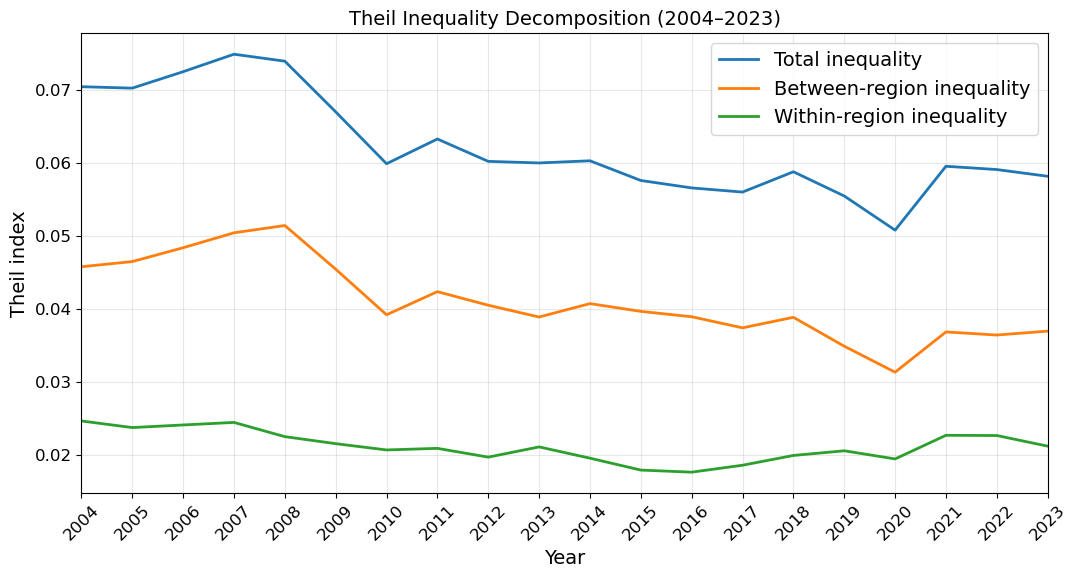

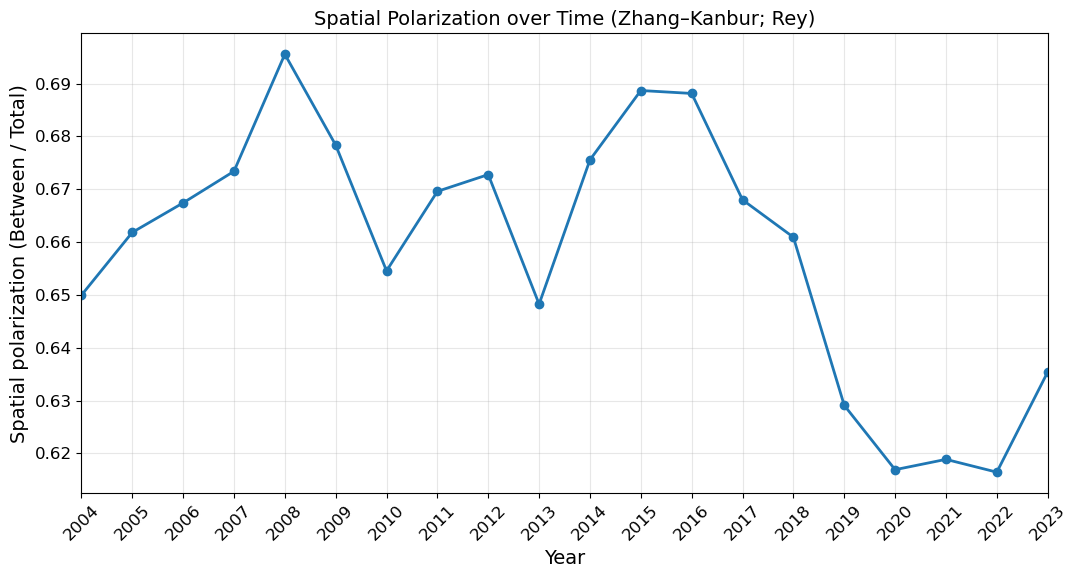

In [576]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from inequality.theil import TheilDSim

# ------------------------------------------------
# GLOBAL PLOT SETTINGS
# ------------------------------------------------
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

np.random.seed(12345)

# ------------------------------------------------
# YEARS AND REGIMES
# ------------------------------------------------
years = list(range(2004, 2024))
regimes = gdf["regionID"]

# Safety check: each regime must have >1 observation
assert gdf.groupby(regimes).size().min() > 1, \
    "Each regionID must contain more than one observation."

# ------------------------------------------------
# COMPUTE THEIL COMPONENTS FOR ALL YEARS
# ------------------------------------------------
results = []

for year in years:

    col = f"gdppc_{year}"

    # Column must exist
    if col not in gdf.columns:
        print(f"WARNING: {col} not found – skipped")
        continue

    income = gdf[col]

    # Column must not be all NaN
    if income.isna().all():
        print(f"WARNING: {col} is all NaN – skipped")
        continue

    res = TheilDSim(income, regimes, permutations=999)

    total = res.T
    between = res.bg[0][0]
    within = total - between                     # Rey identity
    polarization = between / total

    results.append({
        "year": int(year),
        "theil_total": total,
        "theil_between": between,
        "theil_within": within,
        "spatial_polarization": polarization
    })

# ------------------------------------------------
# DATAFRAME (SORTED & CLEAN)
# ------------------------------------------------
df = pd.DataFrame(results).sort_values("year").reset_index(drop=True)

print("Years included:", df["year"].tolist())

# ------------------------------------------------
# FIGURE: THEIL DECOMPOSITION (SINGLE GRAPH)
# ------------------------------------------------
plt.figure(figsize=(11, 6))

plt.plot(df["year"], df["theil_total"],
         label="Total inequality", linewidth=2)

plt.plot(df["year"], df["theil_between"],
         label="Between-region inequality", linewidth=2)

plt.plot(df["year"], df["theil_within"],
         label="Within-region inequality", linewidth=2)

plt.xlabel("Year")
plt.ylabel("Theil index")
plt.title("Theil Inequality Decomposition (2004–2023)")
plt.legend()
plt.grid(alpha=0.3)

# ---- FORCE DISCRETE YEAR AXIS (CRITICAL FIX)
years_plot = df["year"].astype(int).tolist()
plt.xticks(years_plot, years_plot, rotation=45)
plt.xlim(min(years_plot), max(years_plot))

plt.tight_layout()
plt.savefig("theil_decomposition_timeseries_2004_2023.png", dpi=300)
plt.show()

# ------------------------------------------------
# OPTIONAL: SPATIAL POLARIZATION GRAPH (REY)
# ------------------------------------------------
plt.figure(figsize=(11, 6))

plt.plot(
    df["year"],
    df["spatial_polarization"],
    marker="o",
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Spatial polarization (Between / Total)")
plt.title("Spatial Polarization over Time (Zhang–Kanbur; Rey)")
plt.grid(alpha=0.3)

plt.xticks(years_plot, years_plot, rotation=45)
plt.xlim(min(years_plot), max(years_plot))

plt.tight_layout()
plt.savefig("spatial_polarization_timeseries_2004_2023.png", dpi=150)
plt.show()

# ------------------------------------------------
# OPTIONAL: SAVE TABLE
# ------------------------------------------------
df.to_csv("theil_decomposition_2004_2023.csv", index=False)




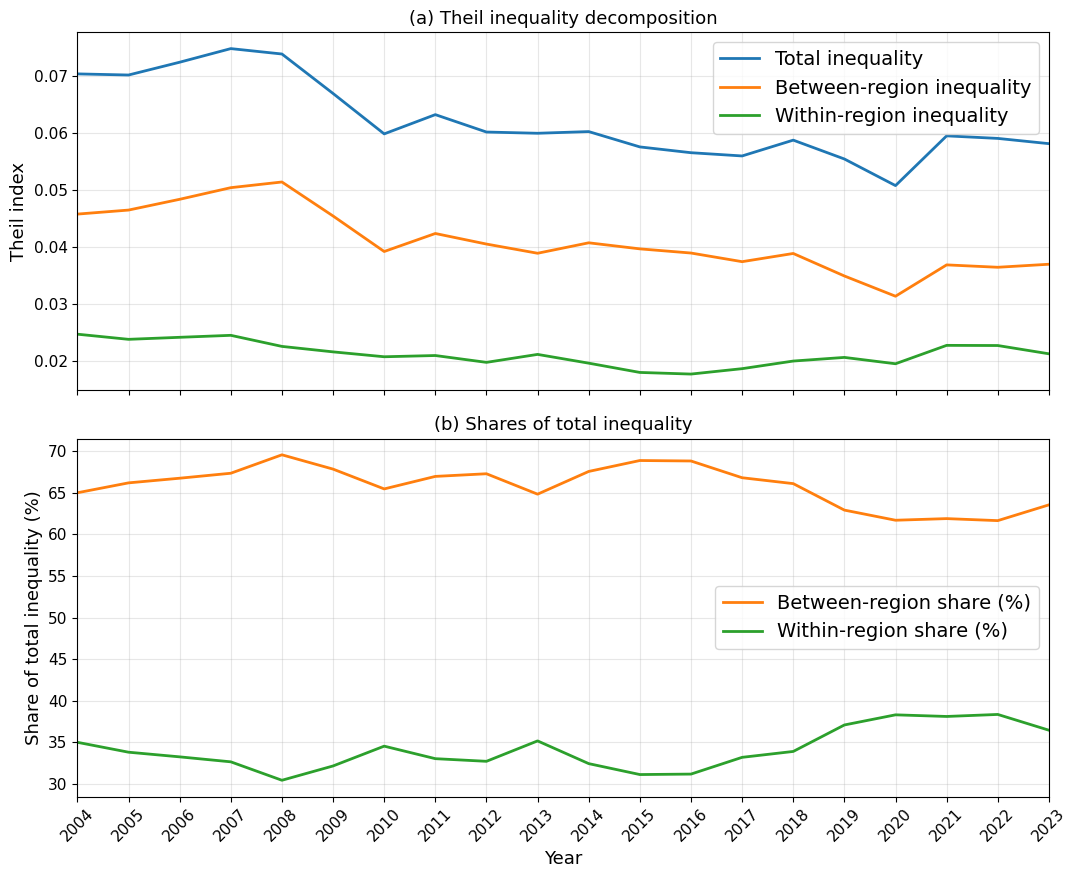

In [577]:


# ------------------------------------------------
# GLOBAL SETTINGS
# ------------------------------------------------
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

np.random.seed(12345)

# ------------------------------------------------
# COLOR PALETTE (CONSISTENT)
# ------------------------------------------------
COLOR_TOTAL   = "#1f77b4"   # blue
COLOR_BETWEEN = "#ff7f0e"   # orange
COLOR_WITHIN  = "#2ca02c"   # green

# ------------------------------------------------
# YEARS AND REGIMES
# ------------------------------------------------
years = list(range(2004, 2024))
regimes = gdf["regionID"]

assert gdf.groupby(regimes).size().min() > 1, \
    "Each regionID must contain more than one observation."

# ------------------------------------------------
# COMPUTE THEIL DECOMPOSITION
# ------------------------------------------------
results = []

for year in years:

    col = f"gdppc_{year}"
    if col not in gdf.columns:
        continue

    income = gdf[col]
    if income.isna().all():
        continue

    res = TheilDSim(income, regimes, permutations=999)

    total = res.T
    between = res.bg[0][0]
    within = total - between

    results.append({
        "year": year,
        "total": total,
        "between": between,
        "within": within,
        "between_pct": 100 * between / total,
        "within_pct": 100 * within / total
    })

df = pd.DataFrame(results).sort_values("year").reset_index(drop=True)

years_plot = df["year"].tolist()

# ------------------------------------------------
# FIGURE 4: TWO-PANEL FIGURE
# ------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(11, 9),
    sharex=True
)

# ==============================
# PANEL A: THEIL LEVELS
# ==============================
ax1.plot(df["year"], df["total"],
         label="Total inequality",
         color=COLOR_TOTAL,
         linewidth=2)

ax1.plot(df["year"], df["between"],
         label="Between-region inequality",
         color=COLOR_BETWEEN,
         linewidth=2)

ax1.plot(df["year"], df["within"],
         label="Within-region inequality",
         color=COLOR_WITHIN,
         linewidth=2)

ax1.set_ylabel("Theil index")
ax1.set_title("(a) Theil inequality decomposition")
ax1.legend()
ax1.grid(alpha=0.3)

# ==============================
# PANEL B: SHARES (%)
# ==============================
ax2.plot(df["year"], df["between_pct"],
         label="Between-region share (%)",
         color=COLOR_BETWEEN,
         linewidth=2)

ax2.plot(df["year"], df["within_pct"],
         label="Within-region share (%)",
         color=COLOR_WITHIN,
         linewidth=2)

ax2.set_ylabel("Share of total inequality (%)")
ax2.set_xlabel("Year")
ax2.set_title("(b) Shares of total inequality")
ax2.legend()
ax2.grid(alpha=0.3)

# ---- Discrete year axis
ax2.set_xticks(years_plot)
ax2.set_xticklabels(years_plot, rotation=45)
ax2.set_xlim(min(years_plot), max(years_plot))

# ------------------------------------------------
# SAVE SINGLE FIGURE
# ------------------------------------------------
plt.tight_layout()
plt.savefig(
    "figure_4_theil_decomposition_and_shares.png",
    dpi=150,
    bbox_inches="tight",
    pad_inches=0.02
)





/opt/anaconda3/lib/python3.12/site-packages/splot/_viz_libpysal_mpl.py:121: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids_shp = gdf.centroid.values
/opt/anaconda3/lib/python3.12/site-packages/splot/_viz_libpysal_mpl.py:164: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf.centroid.plot(ax=ax, **node_kws)


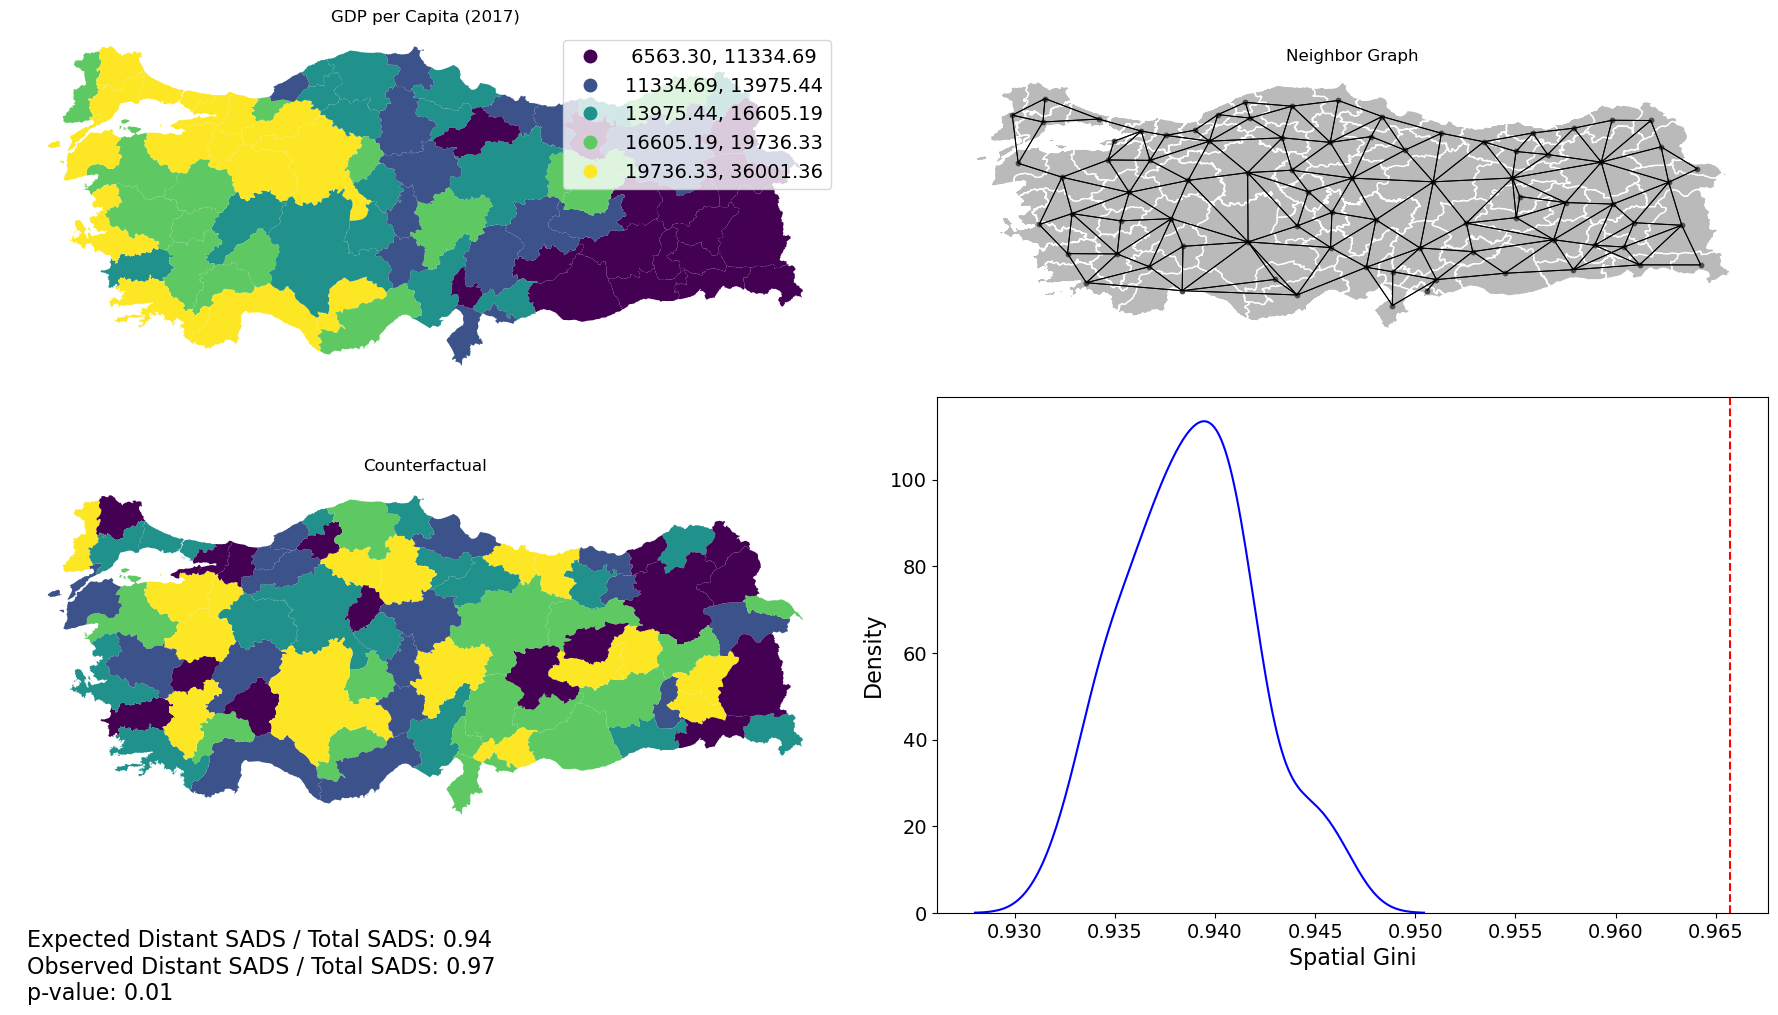

Expected Distant SADS / Total SADS: 0.94
Observed Distant SADS / Total SADS: 0.97
p-value: 0.01


In [578]:


# --- Font ayarları ---
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# --- Random seed ---
np.random.seed(12345)

# --- Step 2: Queen contiguity weight matrix ---
wq = libpysal.weights.Queen.from_dataframe(gdf, use_index=False)
wq.transform = 'B'

# --- Step 3: Set up a 2x2 plot grid ---
fig, axs = plt.subplots(2, 2, figsize=(18, 11))

# --- Panel 1: Map of per capita GDP (2017) ---
gdf.plot(
    column='gdppc_2017',
    ax=axs[0, 0],
    scheme='quantiles',
    cmap='viridis',
    legend=True
)
axs[0, 0].set_title('GDP per Capita (2017)')
axs[0, 0].axis('off')

# --- Panel 2: Queen contiguity graph ---
gdf.plot(ax=axs[0, 1], color='lightblue', edgecolor='white')
plot_spatial_weights(
    wq, gdf, ax=axs[0, 1],
    edge_kws=dict(color='black', linewidth=0.5)
)
axs[0, 1].set_title('Neighbor Graph')
axs[0, 1].axis('off')

# --- Panel 3: Counterfactual (Randomized GDP – 2017) ---
gdf['gdppc_2017r'] = np.random.permutation(gdf['gdppc_2017'].values)
gdf.plot(
    column='gdppc_2017r',
    ax=axs[1, 0],
    scheme='quantiles',
    cmap='viridis'
)
axs[1, 0].set_title('Counterfactual')
axs[1, 0].axis('off')

# --- Step 4: Spatial Gini Simulation (2017) ---
gs = Gini_Spatial(gdf['gdppc_2017'], wq)
adsum = gs.dtotal
realizations = gs.wcgp / adsum
observed = gs.wcg / adsum

# --- Panel 4: KDE plot ---
sns.kdeplot(realizations, fill=False, color='blue', ax=axs[1, 1])
x, y = axs[1, 1].lines[0].get_data()

axs[1, 1].fill_between(
    x, y, where=(x >= observed),
    interpolate=True, color='red', alpha=0.5
)
axs[1, 1].axvline(x=observed, color='red', linestyle='--')
axs[1, 1].set_xlabel("Spatial Gini")
axs[1, 1].set_ylabel("Density")

# --- Summary text ---
summary_text = (
    f"Expected Distant SADS / Total SADS: {gs.e_wcg / adsum:.2f}\n"
    f"Observed Distant SADS / Total SADS: {gs.wcg / adsum:.2f}\n"
    f"p-value: {gs.p_sim:.2f}"
)

axs[1, 0].text(
    0.02, -0.28,
    summary_text,
    fontsize=16,
    ha='left',
    va='top',
    transform=axs[1, 0].transAxes
)

# --- Final Layout ---
plt.tight_layout()
plt.savefig("spatial_gini_2017.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Console output ---
print(f"Expected Distant SADS / Total SADS: {gs.e_wcg / adsum:.2f}")
print(f"Observed Distant SADS / Total SADS: {gs.wcg / adsum:.2f}")
print(f"p-value: {gs.p_sim:.2f}")


/opt/anaconda3/lib/python3.12/site-packages/splot/_viz_libpysal_mpl.py:121: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids_shp = gdf.centroid.values
/opt/anaconda3/lib/python3.12/site-packages/splot/_viz_libpysal_mpl.py:164: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf.centroid.plot(ax=ax, **node_kws)


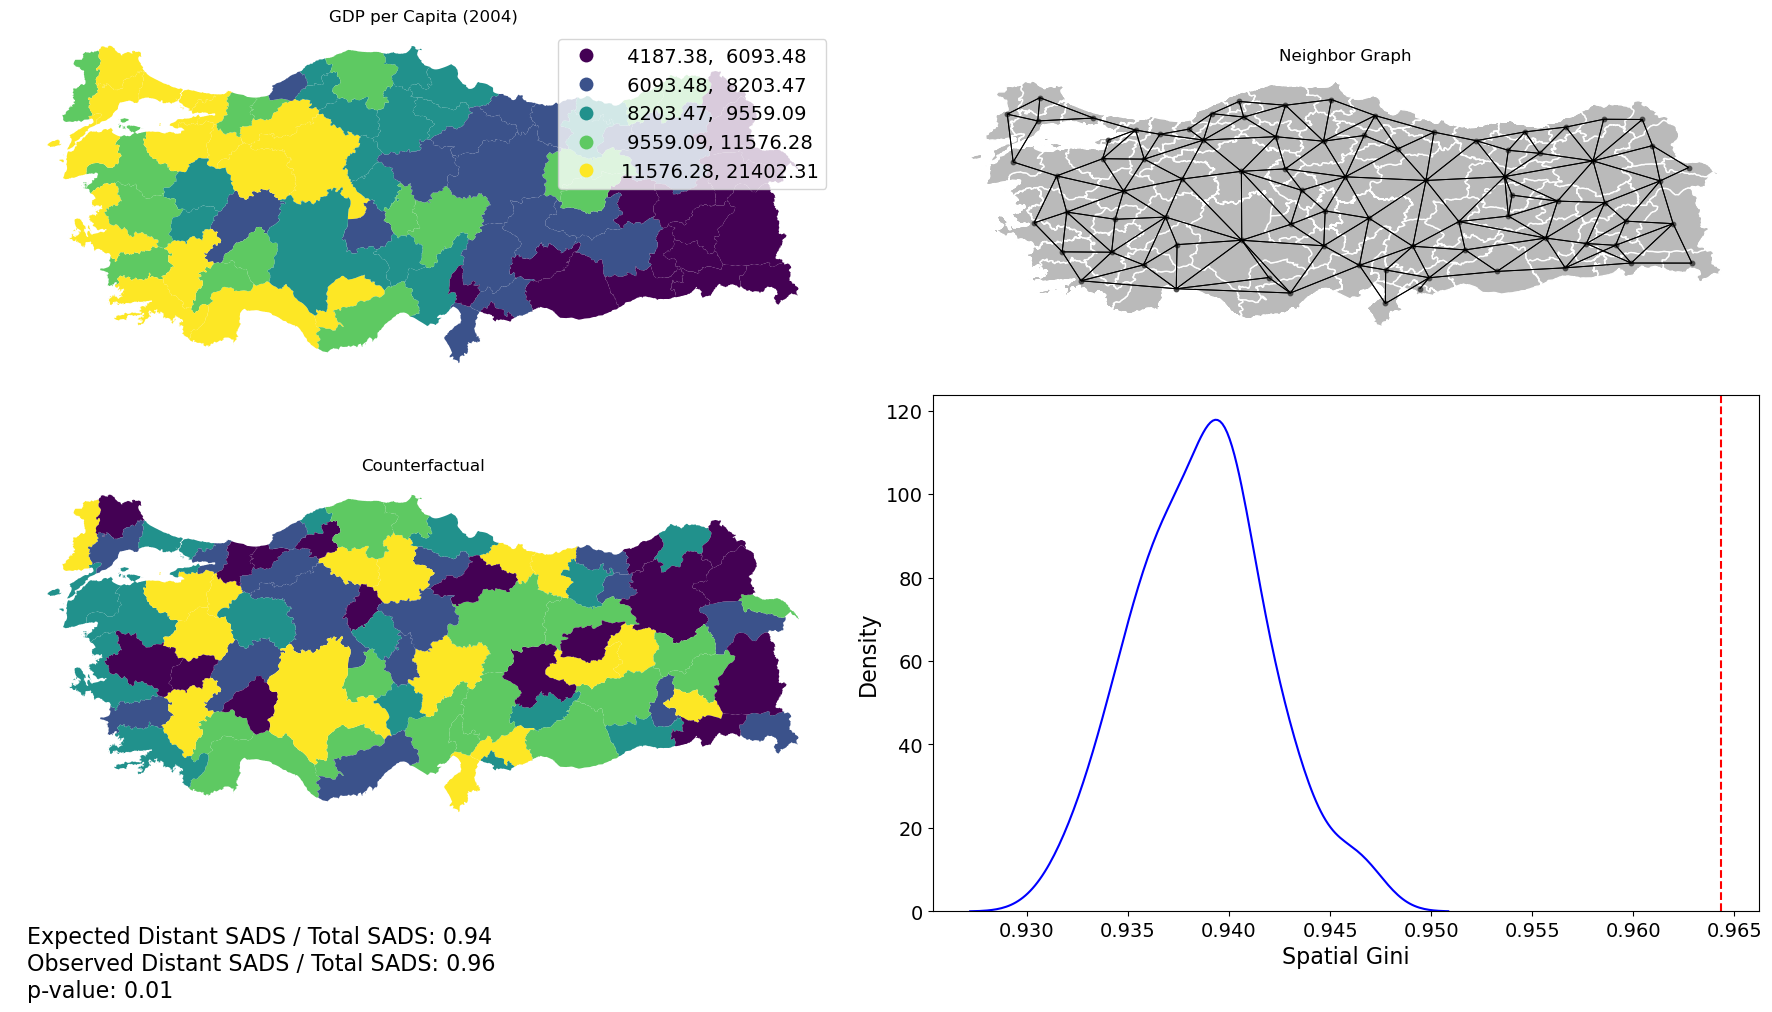

Expected Distant SADS / Total SADS: 0.94
Observed Distant SADS / Total SADS: 0.96
p-value: 0.01


In [579]:
from inequality.gini import Gini_Spatial
import libpysal
from splot.libpysal import plot_spatial_weights
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# --- Font ayarları ---
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# --- Random seed ---
np.random.seed(12345)

# --- Step 2: Queen contiguity weight matrix ---
wq = libpysal.weights.Queen.from_dataframe(gdf, use_index=False)
wq.transform = 'B'

# --- Step 3: 2x2 panel ---
fig, axs = plt.subplots(2, 2, figsize=(18, 11))

# --- Panel 1: Map of per capita GDP (2004) ---
gdf.plot(
    column='gdppc_2004',
    ax=axs[0, 0],
    scheme='quantiles',
    cmap='viridis',
    legend=True
)
axs[0, 0].set_title('GDP per Capita (2004)')
axs[0, 0].axis('off')

# --- Panel 2: Queen contiguity graph ---
gdf.plot(ax=axs[0, 1], color='lightblue', edgecolor='white')
plot_spatial_weights(
    wq, gdf, ax=axs[0, 1],
    edge_kws=dict(color='black', linewidth=0.5)
)
axs[0, 1].set_title('Neighbor Graph')
axs[0, 1].axis('off')

# --- Panel 3: Counterfactual (Randomized GDP – 2004) ---
gdf['gdppc_2004r'] = np.random.permutation(gdf['gdppc_2004'].values)
gdf.plot(
    column='gdppc_2004r',
    ax=axs[1, 0],
    scheme='quantiles',
    cmap='viridis'
)
axs[1, 0].set_title('Counterfactual')
axs[1, 0].axis('off')

# --- Step 4: Spatial Gini Simulation (2004) ---
gs = Gini_Spatial(gdf['gdppc_2004'], wq)
adsum = gs.dtotal
realizations = gs.wcgp / adsum
observed = gs.wcg / adsum

# --- Panel 4: KDE plot ---
sns.kdeplot(realizations, fill=False, color='blue', ax=axs[1, 1])
x, y = axs[1, 1].lines[0].get_data()

axs[1, 1].fill_between(
    x, y, where=(x >= observed),
    interpolate=True, color='red', alpha=0.5
)
axs[1, 1].axvline(x=observed, color='red', linestyle='--')
axs[1, 1].set_xlabel("Spatial Gini")
axs[1, 1].set_ylabel("Density")

# --- Summary text ---
summary_text = (
    f"Expected Distant SADS / Total SADS: {gs.e_wcg / adsum:.2f}\n"
    f"Observed Distant SADS / Total SADS: {gs.wcg / adsum:.2f}\n"
    f"p-value: {gs.p_sim:.2f}"
)

axs[1, 0].text(
    0.02, -0.28,
    summary_text,
    fontsize=16,
    ha='left',
    va='top',
    transform=axs[1, 0].transAxes
)

# --- Final layout ---
plt.tight_layout()
plt.savefig("spatial_gini_2004.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Console output ---
print(f"Expected Distant SADS / Total SADS: {gs.e_wcg / adsum:.2f}")
print(f"Observed Distant SADS / Total SADS: {gs.wcg / adsum:.2f}")
print(f"p-value: {gs.p_sim:.2f}")


In [580]:
print(gdf[['province','regionID']].sort_values('regionID').to_string())

          province regionID
8       BalÄ±kesir      TR2
21       Canakkale      TR2
70       TekirdaÄŸ      TR2
49     KÄ±rklareli      TR2
27          Edirne      TR2
2   Afyonkarahisar      TR3
24         Denizli      TR3
7           AydÄ±n      TR3
58          MuÄŸla      TR3
55          Manisa      TR3
53        KÃ¼tahya      TR3
74           UÅŸak      TR3
40           Izmir      TR3
26          DÃ¼zce      TR4
18            Bolu      TR4
39        Istanbul      TR4
20           Bursa      TR4
31      EskiÅŸehir      TR4
15         Bilecik      TR4
65         Sakarya      TR4
76          Yalova      TR4
51         Kocaeli      TR4
43         Karaman      TR5
9           Ankara      TR5
52           Konya      TR5
36           Hatay      TR6
57          Mersin      TR6
41  KahramanmaraÅŸ      TR6
63        Osmaniye      TR6
38         Isparta      TR6
0            Adana      TR6
5          Antalya      TR6
19          Burdur      TR6
69           Sivas      TR7
61          NiÄŸde  

In [581]:


# gdppc sütunlarını seç
gdppc_cols = [col for col in gdf.columns if col.startswith('gdppc_')]

# Betimsel istatistikler
desc = pd.DataFrame({
    'Year': [col.replace('gdppc_', '') for col in gdppc_cols],
    'Mean': [gdf[col].mean() for col in gdppc_cols],
    'Std': [gdf[col].std() for col in gdppc_cols],
    'Min': [gdf[col].min() for col in gdppc_cols],
    'Max': [gdf[col].max() for col in gdppc_cols],
    'CV': [gdf[col].std() / gdf[col].mean() * 100 for col in gdppc_cols]
})

desc = desc.set_index('Year')
desc = desc.round(2)

print(desc.to_latex(
    caption='Descriptive Statistics of Provincial GDP per Capita, 2004--2023',
    label='tab:desc_stats',
    column_format='lrrrrr',
    float_format='%.2f'
))

\begin{table}
\caption{Descriptive Statistics of Provincial GDP per Capita, 2004--2023}
\label{tab:desc_stats}
\begin{tabular}{lrrrrr}
\toprule
 & Mean & Std & Min & Max & CV \\
Year &  &  &  &  &  \\
\midrule
2004 & 9537.85 & 3719.16 & 4187.38 & 21402.31 & 38.99 \\
2005 & 10249.41 & 3993.65 & 4435.45 & 22887.65 & 38.96 \\
2006 & 10781.71 & 4275.99 & 4346.81 & 24058.80 & 39.66 \\
2007 & 11126.41 & 4495.80 & 4321.64 & 25413.82 & 40.41 \\
2008 & 11152.21 & 4451.45 & 4168.36 & 25109.89 & 39.92 \\
2009 & 10563.24 & 4003.86 & 4251.64 & 23256.62 & 37.90 \\
2010 & 11350.54 & 4075.64 & 5051.13 & 24507.76 & 35.91 \\
2011 & 12376.24 & 4569.71 & 5145.91 & 26891.31 & 36.92 \\
2012 & 12792.92 & 4612.21 & 5466.87 & 28174.53 & 36.05 \\
2013 & 13581.47 & 4901.69 & 5667.76 & 30251.86 & 36.09 \\
2014 & 14030.47 & 5051.04 & 5524.03 & 31602.95 & 36.00 \\
2015 & 14635.08 & 5152.58 & 5817.80 & 33166.76 & 35.21 \\
2016 & 14916.74 & 5210.27 & 6527.34 & 33718.53 & 34.93 \\
2017 & 15799.24 & 5499.00 & 6563.30 &

In [582]:
selected_years = ['2004', '2023']
selected_cols = [f'gdppc_{y}' for y in selected_years]

rows = []
for col, year in zip(selected_cols, selected_years):
    vals = gdf[col].values
    rows.append({
        'Year': year,
        'Observations': len(vals),
        'Mean': vals.mean(),
        'Std': vals.std(),
        'Min': vals.min(),
        'Max': vals.max(),
        'CV': vals.std() / vals.mean() * 100
    })

desc_selected = pd.DataFrame(rows).set_index('Year').round(2)

print(desc_selected.to_latex(
    caption='Descriptive Statistics of Provincial GDP per Capita, 2004 and 2023',
    label='tab:desc_stats',
    column_format='lrrrrrr',
    float_format='%.2f'
))

\begin{table}
\caption{Descriptive Statistics of Provincial GDP per Capita, 2004 and 2023}
\label{tab:desc_stats}
\begin{tabular}{lrrrrrr}
\toprule
 & Observations & Mean & Std & Min & Max & CV \\
Year &  &  &  &  &  &  \\
\midrule
2004 & 81 & 9537.85 & 3696.13 & 4187.38 & 21402.31 & 38.75 \\
2023 & 81 & 18812.14 & 6749.18 & 9370.54 & 45809.09 & 35.88 \\
\bottomrule
\end{tabular}
\end{table}



In [583]:
selected_years = ['2004', '2023']
selected_cols = [f'gdppc_{y}' for y in selected_years]

rows = []
for col, year in zip(selected_cols, selected_years):
    vals = gdf[col].values
    rows.append({
        'Year': year,
        'Observations': len(vals),
        'Mean': vals.mean(),
        'Median': np.median(vals),
        'Std': vals.std(),
        'Min': vals.min(),
        'Max': vals.max()
    })

desc_selected = pd.DataFrame(rows).set_index('Year').round(2)

print(desc_selected.to_latex(
    caption='Descriptive Statistics of Provincial GDP per Capita, 2004 and 2023',
    label='tab:desc_stats',
    column_format='lrrrrrrr',
    float_format='%.2f'
))

\begin{table}
\caption{Descriptive Statistics of Provincial GDP per Capita, 2004 and 2023}
\label{tab:desc_stats}
\begin{tabular}{lrrrrrrr}
\toprule
 & Observations & Mean & Median & Std & Min & Max \\
Year &  &  &  &  &  &  \\
\midrule
2004 & 81 & 9537.85 & 8832.41 & 3696.13 & 4187.38 & 21402.31 \\
2023 & 81 & 18812.14 & 17535.22 & 6749.18 & 9370.54 & 45809.09 \\
\bottomrule
\end{tabular}
\end{table}



In [584]:
mean_2004 = gdf['gdppc_2004'].mean()
mean_2023 = gdf['gdppc_2023'].mean()
std_2004 = gdf['gdppc_2004'].std()
std_2023 = gdf['gdppc_2023'].std()

ratio_mean = mean_2004 / mean_2023
ratio_std = std_2004 / std_2023

print(f"Mean 2004: {mean_2004:.2f}")
print(f"Mean 2023: {mean_2023:.2f}")
print(f"Mean ratio: {ratio_mean:.2f}")
print(f"Std 2004: {std_2004:.2f}")
print(f"Std 2023: {std_2023:.2f}")
print(f"Std ratio: {ratio_std:.2f}")

Mean 2004: 9537.85
Mean 2023: 18812.14
Mean ratio: 0.51
Std 2004: 3719.16
Std 2023: 6791.23
Std ratio: 0.55


/var/folders/9n/2npp5rt91xx7jjcns1fqcnt00000gn/T/ipykernel_19786/2075574667.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap       = plt.cm.get_cmap('tab20', len(nuts1_ids))


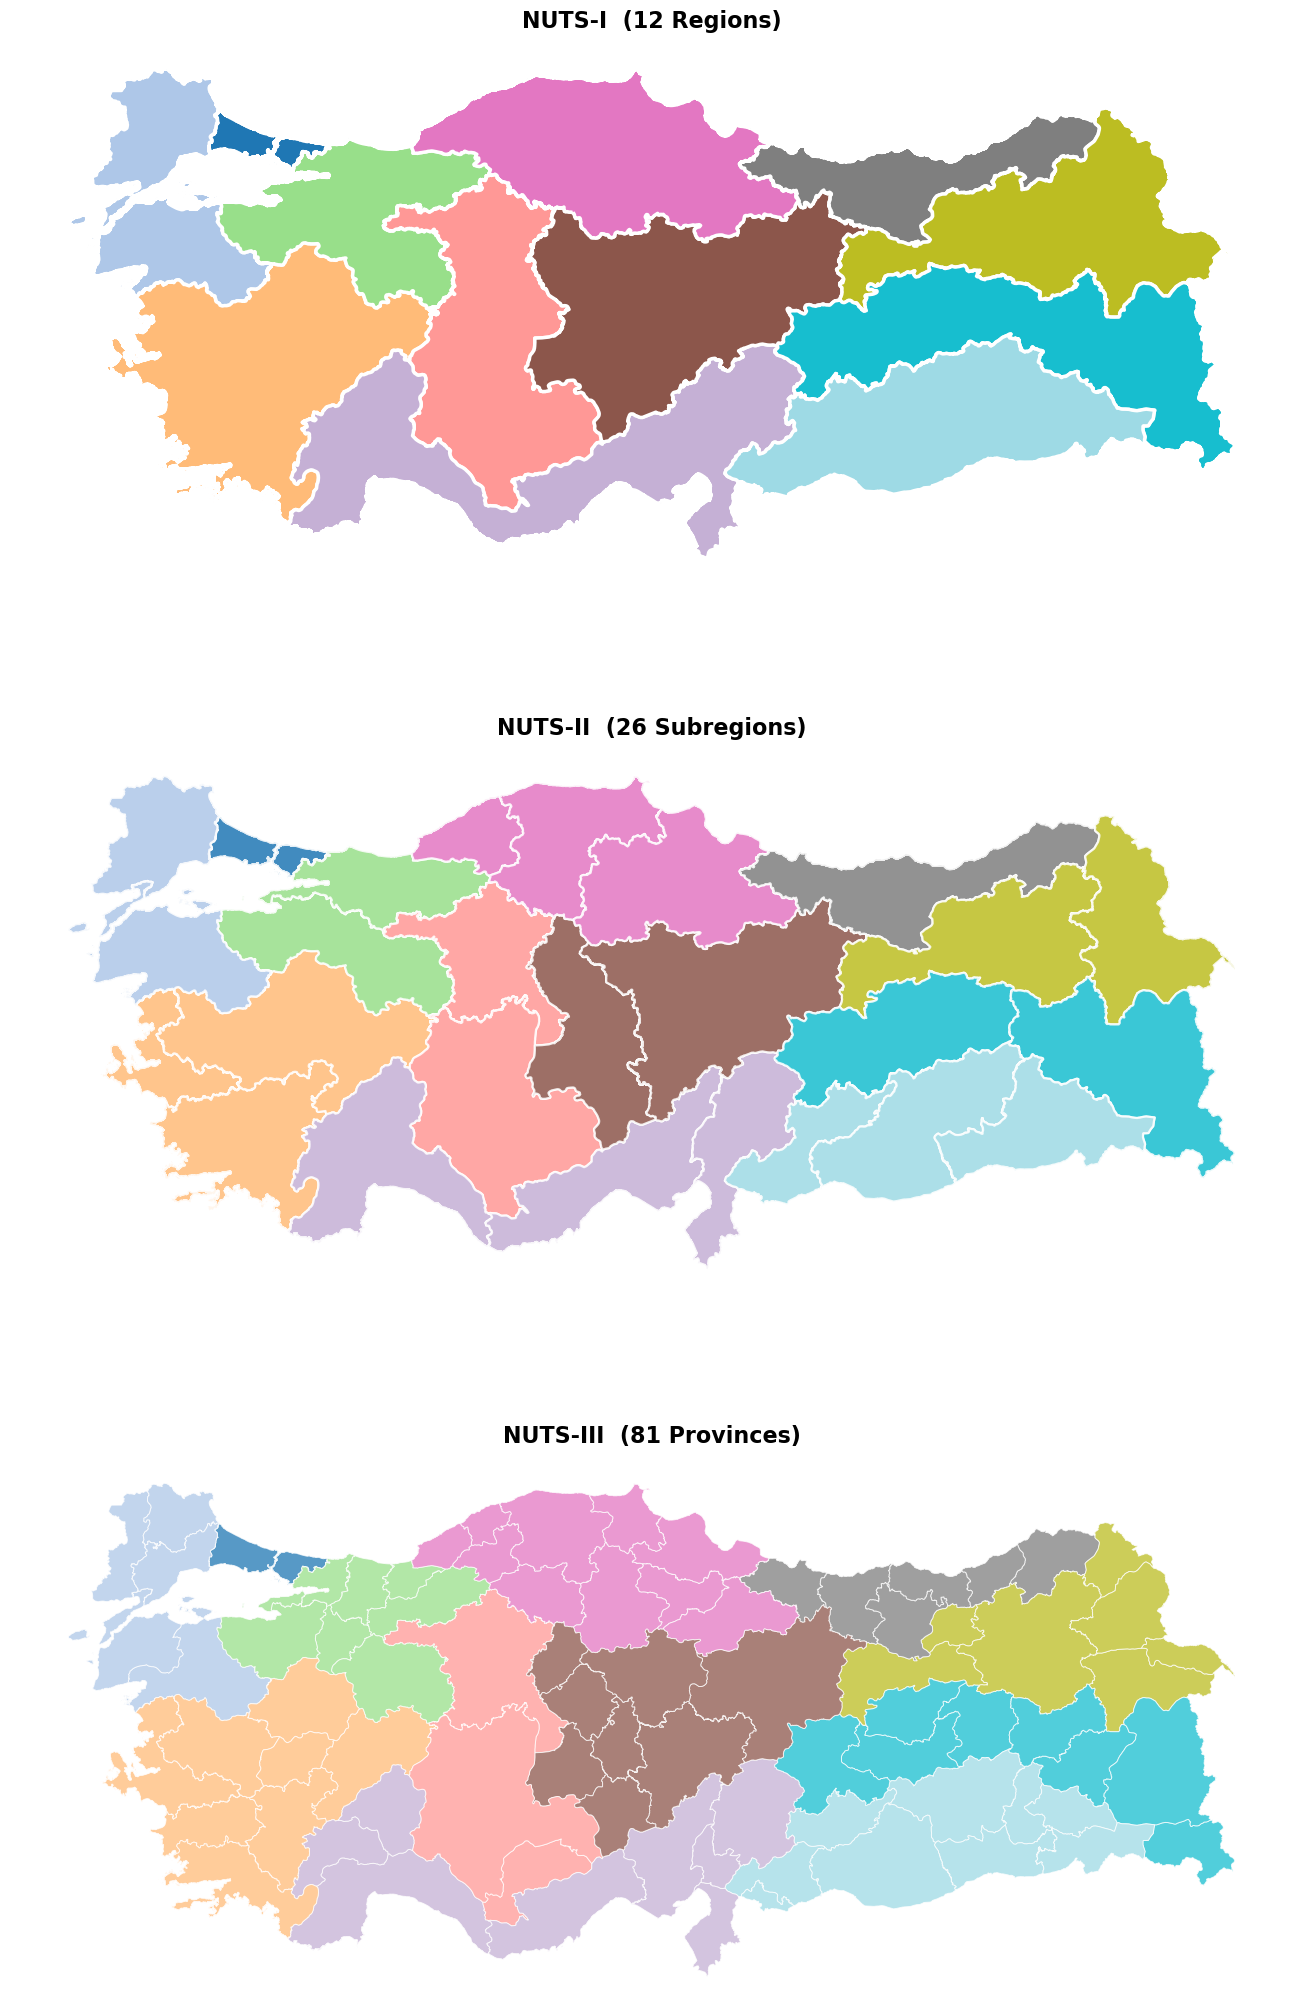

In [585]:
import matplotlib.pyplot as plt

# --- İstanbul TR1'e alınıyor (harita için) ---
gdf_map = gdf.copy()
gdf_map.loc[gdf_map['province'] == 'Istanbul', 'regionID'] = 'TR1'
gdf_map.loc[gdf_map['province'] == 'Istanbul', 'region']   = 'İstanbul'

# --- Dissolve ---
gdf_nuts1 = gdf_map.dissolve(by='regionID',    aggfunc='first').reset_index()
gdf_nuts2 = gdf_map.dissolve(by='subregionID', aggfunc='first').reset_index()

# --- Renk haritası: 12 NUTS-I bölgesi → farklı renkler ---
nuts1_ids  = sorted(gdf_nuts1['regionID'].unique())
cmap       = plt.cm.get_cmap('tab20', len(nuts1_ids))
color_dict = {rid: cmap(i) for i, rid in enumerate(nuts1_ids)}

# regionID sütunu dissolve sonrası korunuyor — doğrudan kullan
gdf_nuts1['color'] = gdf_nuts1['regionID'].map(color_dict)
gdf_nuts2['color'] = gdf_nuts2['regionID'].map(color_dict)
gdf_map['color']   = gdf_map['regionID'].map(color_dict)

# --- Figure: 3 satır, 1 sütun ---
fig, axes = plt.subplots(3, 1, figsize=(14, 22))

for ax in axes:
    ax.set_facecolor('#f5f5f5')

# ── NUTS-I ───────────────────────────────────────────────────────────────────
gdf_nuts1.plot(
    ax=axes[0],
    color=gdf_nuts1['color'],
    edgecolor='white',
    linewidth=2.5
)
axes[0].set_title('NUTS-I  (12 Regions)', fontsize=16, fontweight='bold', pad=12)
axes[0].axis('off')

# ── NUTS-II ──────────────────────────────────────────────────────────────────
gdf_nuts2.plot(
    ax=axes[1],
    color=gdf_nuts2['color'],
    edgecolor='white',
    linewidth=1.6,
    alpha=0.85
)
axes[1].set_title('NUTS-II  (26 Subregions)', fontsize=16, fontweight='bold', pad=12)
axes[1].axis('off')

# ── NUTS-III ─────────────────────────────────────────────────────────────────
gdf_map.plot(
    ax=axes[2],
    color=gdf_map['color'],
    edgecolor='white',
    linewidth=0.7,
    alpha=0.75
)
axes[2].set_title('NUTS-III  (81 Provinces)', fontsize=16, fontweight='bold', pad=12)
axes[2].axis('off')

plt.tight_layout(pad=3.0)
plt.savefig('nuts_classification_maps_v2.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()